In [1]:
# Install dependencies (run once in Colab)
!pip install -q kaggle
!pip install -q mediapipe  # needed for inference later

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 72.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 9.0 MB/s eta 0:00:00


In [2]:
# ── Core imports ─────────────────────────────────────────────────────────────
import os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, applications, callbacks
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix

print(f"TensorFlow  : {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Save directory (local — no Drive needed) ─────────────────────────────────
SAVE_DIR = '/content/asl_models'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Models will be saved to: {SAVE_DIR}")

TensorFlow  : 2.19.0
GPU available: True
Models will be saved to: /content/asl_models


In [3]:
import os

# ── Set up Kaggle credentials ─────────────────────────────────────────────────
# Option A: paste your token inline (replace with your actual credentials)
import json
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
# Uncomment and fill in if kaggle.json is not already in place:
# token = {"username": "YOUR_KAGGLE_USERNAME", "key": "YOUR_KAGGLE_KEY"}
# with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'w') as f:
#     json.dump(token, f)
# os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)

# ── Download & extract dataset ────────────────────────────────────────────────
!pip install kaggle -q
!kaggle datasets download -d datamunge/sign-language-mnist -p /content/data
!unzip -q /content/data/sign-language-mnist.zip -d /content/data
!ls /content/data

Dataset URL: https://www.kaggle.com/datasets/datamunge/sign-language-mnist
License(s): CC0-1.0
100% 62.6M/62.6M [00:00<00:00, 108MB/s]

american_sign_language.PNG  sign-language-mnist.zip  sign_mnist_train
amer_sign2.png		    sign_mnist_test	     sign_mnist_train.csv
amer_sign3.png		    sign_mnist_test.csv


In [4]:
# ── Load CSVs ────────────────────────────────────────────────────────────────
train_df = pd.read_csv('/content/data/sign_mnist_train/sign_mnist_train.csv')
test_df  = pd.read_csv('/content/data/sign_mnist_test/sign_mnist_test.csv')

print(f"Train shape : {train_df.shape}")
print(f"Test  shape : {test_df.shape}")
print(f"Unique labels: {sorted(train_df['label'].unique())}")
train_df.head()

Train shape : (27455, 785)
Test  shape : (7172, 785)
Unique labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


In [5]:
# ── Label mapping ─────────────────────────────────────────────────────────────
# 0-25 maps to A-Z; J(9) and Z(25) are omitted → 24 classes
# The dataset labels skip 9 & 25, using 0-23 sequentially after removal
# Build a display name map
ALPHABET = 'ABCDEFGHIJKLMNOPQRSTUVWXYZ'
# Kaggle label → letter (0=A,1=B,...8=I, 10=K...)
# Note: labels in the CSV already skip J(9) & Z(25)
label_to_letter = {i: ALPHABET[i] for i in range(26) if i not in (9, 25)}
NUM_CLASSES = 24

print("Label mapping:", label_to_letter)
print(f"Number of classes: {NUM_CLASSES}")

Label mapping: {0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E', 5: 'F', 6: 'G', 7: 'H', 8: 'I', 10: 'K', 11: 'L', 12: 'M', 13: 'N', 14: 'O', 15: 'P', 16: 'Q', 17: 'R', 18: 'S', 19: 'T', 20: 'U', 21: 'V', 22: 'W', 23: 'X', 24: 'Y'}
Number of classes: 24


In [6]:
# ── Parse pixels ─────────────────────────────────────────────────────────────
def parse_df(df):
    y = df['label'].values
    X = df.drop('label', axis=1).values.reshape(-1, 28, 28).astype('float32')
    return X, y

X_train_raw, y_train = parse_df(train_df)
X_test_raw,  y_test  = parse_df(test_df)

print(f"X_train: {X_train_raw.shape}  y_train: {y_train.shape}")
print(f"X_test : {X_test_raw.shape}   y_test : {y_test.shape}")
print(f"Pixel range: [{X_train_raw.min()}, {X_train_raw.max()}]")
print(f"Raw unique labels: {sorted(np.unique(y_train))}")

# ── FIX: Remap labels to contiguous 0…23 ─────────────────────────────────────
# The CSV labels are 0-8 then 10-24 (J=9 and Z=25 are absent).
# sparse_categorical_crossentropy requires labels in [0, NUM_CLASSES-1].
# Label 24 would index position 24 on a 24-unit softmax → out-of-bounds → NaN!
unique_labels = sorted(np.unique(y_train))          # [0,1,..,8,10,..,24]
label_remap   = {old: new for new, old in enumerate(unique_labels)}
y_train = np.array([label_remap[l] for l in y_train], dtype='int32')
y_test  = np.array([label_remap[l] for l in y_test],  dtype='int32')

# Re-build display map with new indices
label_to_letter = {new: label_to_letter[old] for old, new in label_remap.items()}

print(f"Remapped labels → {sorted(np.unique(y_train))}  (now contiguous 0-23)")


X_train: (27455, 28, 28)  y_train: (27455,)
X_test : (7172, 28, 28)   y_test : (7172,)
Pixel range: [0.0, 255.0]
Raw unique labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]
Remapped labels → [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23)]  (now contiguous 0-23)


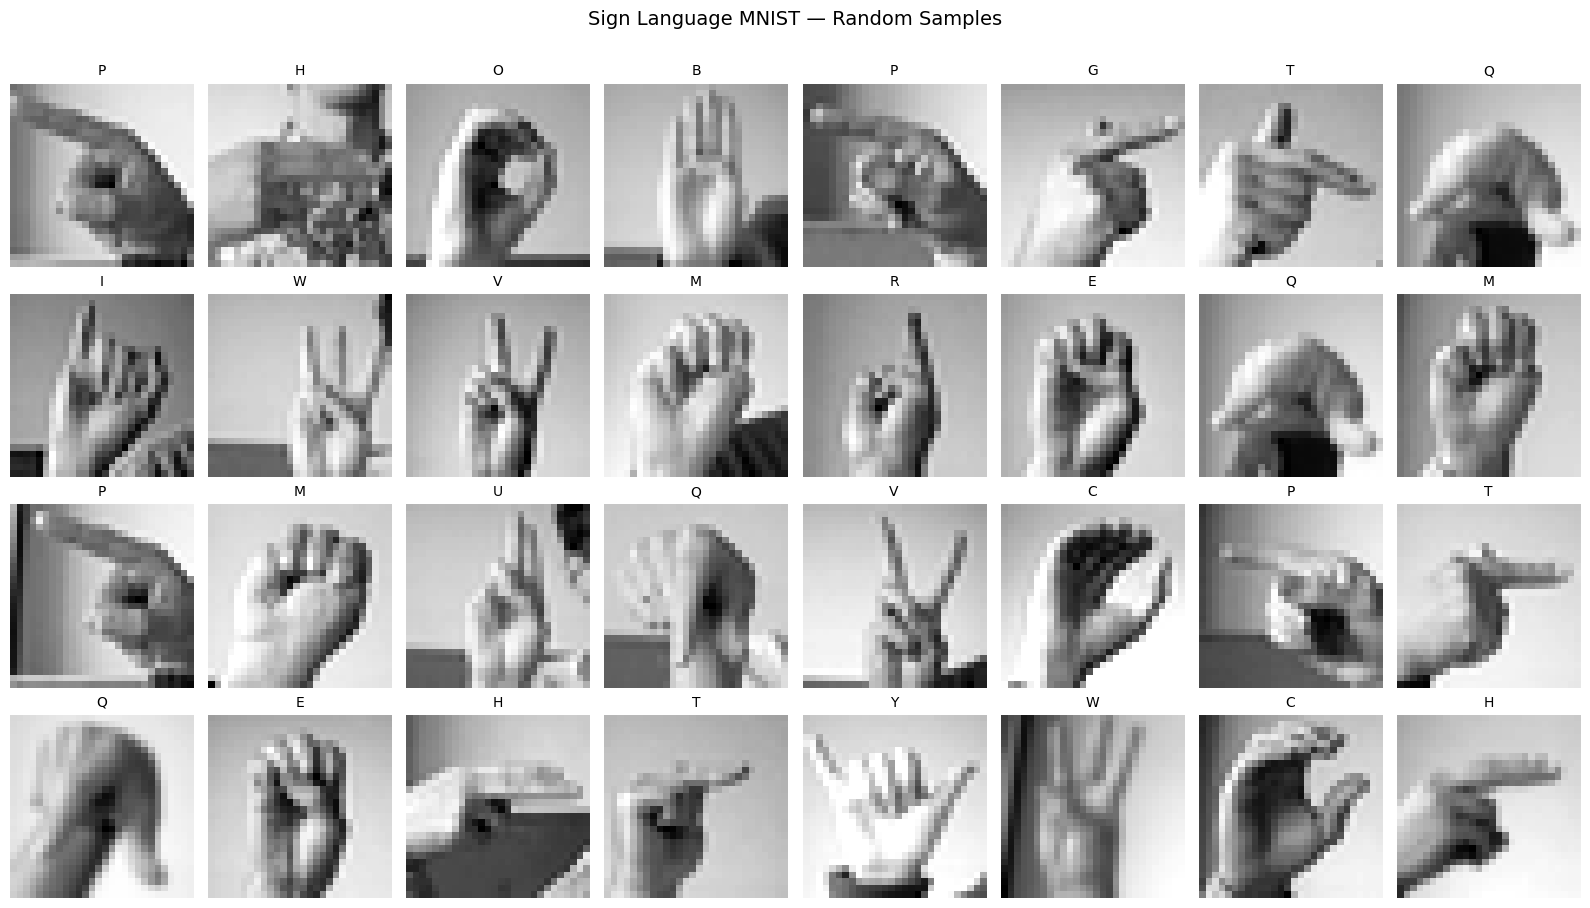

In [7]:
# ── Visualise sample images ───────────────────────────────────────────────────
fig, axes = plt.subplots(4, 8, figsize=(16, 9))
for i, ax in enumerate(axes.flat):
    idx = np.random.randint(len(X_train_raw))
    ax.imshow(X_train_raw[idx], cmap='gray')
    ax.set_title(label_to_letter.get(y_train[idx], '?'), fontsize=10)
    ax.axis('off')
plt.suptitle('Sign Language MNIST — Random Samples', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

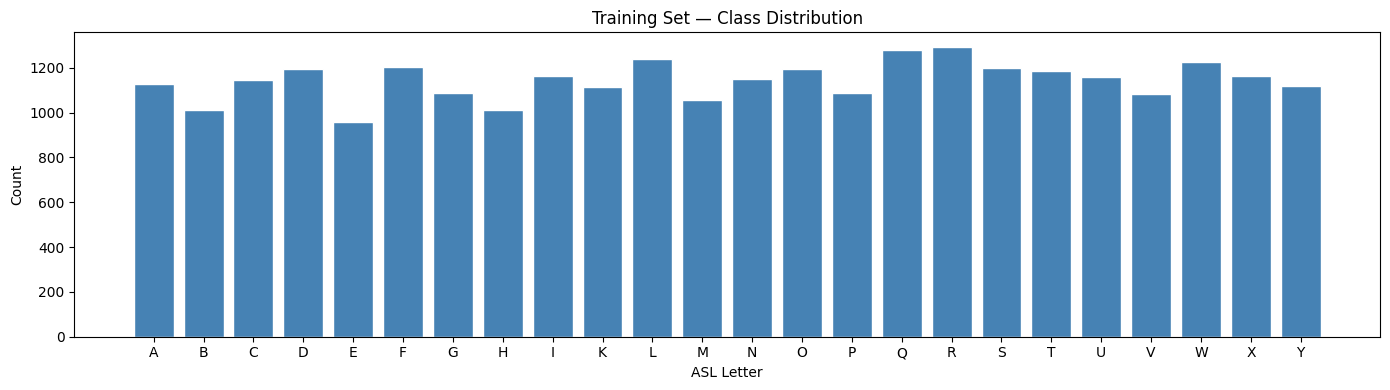

Min samples per class: 957 | Max: 1294


In [8]:
# ── Class distribution ────────────────────────────────────────────────────────
unique, counts = np.unique(y_train, return_counts=True)
labels_str = [label_to_letter.get(l, str(l)) for l in unique]

plt.figure(figsize=(14, 4))
plt.bar(labels_str, counts, color='steelblue', edgecolor='white')
plt.title('Training Set — Class Distribution')
plt.xlabel('ASL Letter')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
print(f"Min samples per class: {counts.min()} | Max: {counts.max()}")

In [9]:
# ── Shared augmentation layer (used for all models) ───────────────────────────
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.05, 0.05),
], name='augmentation')


def prep_lenet(X, y):
    """28×28 grayscale, shape (N,28,28,1), labels as ints."""
    return X.reshape(-1, 28, 28, 1) / 255.0, y


def prep_alexnet(X, y, size=227):
    """Resize grayscale → RGB 227×227, labels as ints."""
    imgs = []
    for img in X:
        rgb = np.stack([img, img, img], axis=-1)   # gray → 3-channel
        rgb = tf.image.resize(rgb, (size, size)).numpy()
        imgs.append(rgb)
    return np.array(imgs, dtype='float32') / 255.0, y


def prep_transfer(X, y, size=224, preprocess_fn=None):
    """Resize grayscale → RGB (size×size), apply model-specific preprocessing."""
    imgs = []
    for img in X:
        rgb = np.stack([img, img, img], axis=-1)
        rgb = tf.image.resize(rgb, (size, size)).numpy()
        imgs.append(rgb)
    imgs = np.array(imgs, dtype='float32')
    if preprocess_fn is not None:
        imgs = preprocess_fn(imgs)
    return imgs, y


# ── Utility: plot training curves ─────────────────────────────────────────────
def plot_history(history, title='Training History'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    ax1.plot(history.history['accuracy'],     label='train')
    ax1.plot(history.history['val_accuracy'], label='val')
    ax1.set_title(f'{title} — Accuracy'); ax1.legend(); ax1.set_xlabel('Epoch')
    ax2.plot(history.history['loss'],     label='train')
    ax2.plot(history.history['val_loss'], label='val')
    ax2.set_title(f'{title} — Loss');     ax2.legend(); ax2.set_xlabel('Epoch')
    plt.tight_layout()
    plt.show()


# ── Utility: evaluate and show confusion matrix ───────────────────────────────
def evaluate_model(model, X_test, y_test, model_name, label_map):
    # ── Run inference ──────────────────────────────────────────────────────────
    if isinstance(X_test, tf.data.Dataset):
        preds = np.concatenate([model(xb, training=False).numpy()
                                for xb, _ in X_test], axis=0)
    else:
        # Call model directly — avoids the optree/None bug in model.evaluate()
        preds = np.concatenate(
            [model(X_test[i:i+256], training=False).numpy()
             for i in range(0, len(X_test), 256)], axis=0
        )

    y_pred = np.argmax(preds, axis=1)

    # ── Compute loss & accuracy manually ──────────────────────────────────────
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()
    loss = float(loss_fn(y_test, preds).numpy())
    acc  = float(np.mean(y_pred == y_test))

    # ── Report ─────────────────────────────────────────────────────────────────
    classes = [label_map.get(l, str(l)) for l in sorted(np.unique(y_test))]
    print(f"\n{'='*50}")
    print(f"  {model_name}")
    print(f"  Test Loss: {loss:.4f}  |  Test Accuracy: {acc*100:.2f}%")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, target_names=classes, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(14, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'{model_name} — Confusion Matrix')
    plt.tight_layout()
    plt.show()
    return acc

print("Helpers defined ✓")

Helpers defined ✓


In [10]:
# ── Prepare data ─────────────────────────────────────────────────────────────
x_train_lenet, y_train_lenet = prep_lenet(X_train_raw, y_train)
x_test_lenet,  y_test_lenet  = prep_lenet(X_test_raw,  y_test)
print(f"LeNet input shape: {x_train_lenet.shape}")

LeNet input shape: (27455, 28, 28, 1)


In [11]:
# ── Build LeNet-5 ─────────────────────────────────────────────────────────────
lenet = models.Sequential([
    # Augmentation
    layers.Input(shape=(28, 28, 1)),
    data_augmentation,

    # Conv Block 1 — C1 + S2
    layers.Conv2D(6, (5, 5), activation='tanh', padding='same'),
    layers.AveragePooling2D(pool_size=(2, 2)),

    # Conv Block 2 — C3 + S4
    layers.Conv2D(16, (5, 5), activation='tanh'),
    layers.AveragePooling2D(pool_size=(2, 2)),

    # Flatten + FC
    layers.Flatten(),
    layers.Dense(120, activation='tanh'),
    layers.Dense(84,  activation='tanh'),

    # Output — 24 ASL classes
    layers.Dense(NUM_CLASSES, activation='softmax'),
], name='LeNet5')

lenet.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
lenet.summary()

Model: "LeNet5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 14, 14, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 24)             │         2,040 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,896 (245.69 KB)

 Trainable params: 62,896 (245.69 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
387/387 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2630 - loss: 2.4579
Epoch 1: val_loss improved from None to 1.07166, saving model to /content/asl_models/lenet_sign.h5



Epoch 1: finished saving model to /content/asl_models/lenet_sign.h5
387/387 ━━━━━━━━━━━━━━━━━━━━ 19s 17ms/step - accuracy: 0.3885 - loss: 2.0079 - val_accuracy: 0.6832 - val_loss: 1.0717 - learning_rate: 0.0010
Epoch 2/30
387/387 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5624 - loss: 1.3972
Epoch 2: val_loss improved from 1.07166 to 0.68171, saving model to /content/asl_models/lenet_sign.h5



Epoch 2: finished saving model to /content/asl_models/lenet_sign.h5
387/387 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.5989 - loss: 1.2864 - val_accuracy: 0.8296 - val_loss: 0.6817 - learning_rate: 0.0010
Epoch 3/30
380/387 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6865 - loss: 1.0202
Epoch 3: val_loss improved from 0.68171 to 0.44268, saving model to /content/asl_models/lenet_sign.h5



Epoch 3: finished saving model to /content/asl_models/lenet_sign.h5
387/387 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7144 - loss: 0.9397 - val_accuracy: 0.9006 - val_loss: 0.4427 - learning_rate: 0.0010
Epoch 4/30
383/387 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7616 - loss: 0.7775
Epoch 4: val_loss improved from 0.44268 to 0.30641, saving model to /content/asl_models/lenet_sign.h5



Epoch 4: finished saving model to /content/asl_models/lenet_sign.h5
387/387 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7804 - loss: 0.7182 - val_accuracy: 0.9363 - val_loss: 0.3064 - learning_rate: 0.0010
Epoch 5/30
386/387 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8149 - loss: 0.6193
Epoch 5: val_loss improved from 0.30641 to 0.21667, saving model to /content/asl_models/lenet_sign.h5


...


Epoch 17: finished saving model to /content/asl_models/lenet_sign.h5
387/387 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9663 - loss: 0.1169 - val_accuracy: 0.9993 - val_loss: 0.0222 - learning_rate: 0.0010
Epoch 18/30
381/387 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9621 - loss: 0.1280
Epoch 18: val_loss did not improve from 0.02221
387/387 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9672 - loss: 0.1158 - val_accuracy: 0.9967 - val_loss: 0.0268 - learning_rate: 0.0010
Epoch 19/30
381/387 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9751 - loss: 0.0929
Epoch 19: val_loss did not improve from 0.02221
387/387 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9728 - loss: 0.0950 - val_accuracy: 0.9971 - val_loss: 0.0237 - learning_rate: 0.0010
Epoch 20/30
381/387 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9711 - loss: 0.0957
Epoch 20: val_loss improved from 0.02221 to 0.01476, saving model to /content/asl_models/lenet_sign.h5



Epoch 20: finished saving model to /content/asl_models/lenet_sign.h5
387/387 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9720 - loss: 0.0945 - val_accuracy: 0.9996 - val_loss: 0.0148 - learning_rate: 0.0010
Epoch 21/30
385/387 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9769 - loss: 0.0822
Epoch 21: val_loss did not improve from 0.01476
387/387 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9776 - loss: 0.0802 - val_accuracy: 0.9934 - val_loss: 0.0245 - learning_rate: 0.0010
Epoch 22/30
387/387 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9648 - loss: 0.1118
Epoch 22: val_loss did not improve from 0.01476
387/387 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9714 - loss: 0.0952 - val_accuracy: 0.9956 - val_loss: 0.0211 - learning_rate: 0.0010
Epoch 23/30
386/387 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9793 - loss: 0.0729
Epoch 23: val_loss improved from 0.01476 to 0.01150, saving model to /content/asl_models/lenet_sign.h5



Epoch 23: finished saving model to /content/asl_models/lenet_sign.h5
387/387 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9800 - loss: 0.0729 - val_accuracy: 0.9978 - val_loss: 0.0115 - learning_rate: 0.0010
Epoch 24/30
383/387 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9773 - loss: 0.0736
Epoch 24: val_loss did not improve from 0.01150
387/387 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9781 - loss: 0.0728 - val_accuracy: 0.9967 - val_loss: 0.0179 - learning_rate: 0.0010
Epoch 25/30
380/387 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9777 - loss: 0.0726
Epoch 25: val_loss improved from 0.01150 to 0.00762, saving model to /content/asl_models/lenet_sign.h5



Epoch 25: finished saving model to /content/asl_models/lenet_sign.h5
387/387 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9798 - loss: 0.0679 - val_accuracy: 1.0000 - val_loss: 0.0076 - learning_rate: 0.0010
Epoch 26/30
386/387 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9793 - loss: 0.0694
Epoch 26: val_loss did not improve from 0.00762
387/387 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9797 - loss: 0.0694 - val_accuracy: 0.9982 - val_loss: 0.0112 - learning_rate: 0.0010
Epoch 27/30
385/387 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9796 - loss: 0.0666
Epoch 27: val_loss did not improve from 0.00762
387/387 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9799 - loss: 0.0663 - val_accuracy: 0.9975 - val_loss: 0.0141 - learning_rate: 0.0010
Epoch 28/30
379/387 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9798 - loss: 0.0674
Epoch 28: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 28: val_loss did not improve from 0.00762
387/387 ━━━━━━━━━━━━━━━━


Epoch 29: finished saving model to /content/asl_models/lenet_sign.h5
387/387 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9903 - loss: 0.0384 - val_accuracy: 1.0000 - val_loss: 0.0051 - learning_rate: 5.0000e-04
Epoch 30/30
384/387 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9920 - loss: 0.0331
Epoch 30: val_loss did not improve from 0.00507
387/387 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9914 - loss: 0.0346 - val_accuracy: 1.0000 - val_loss: 0.0055 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 29.


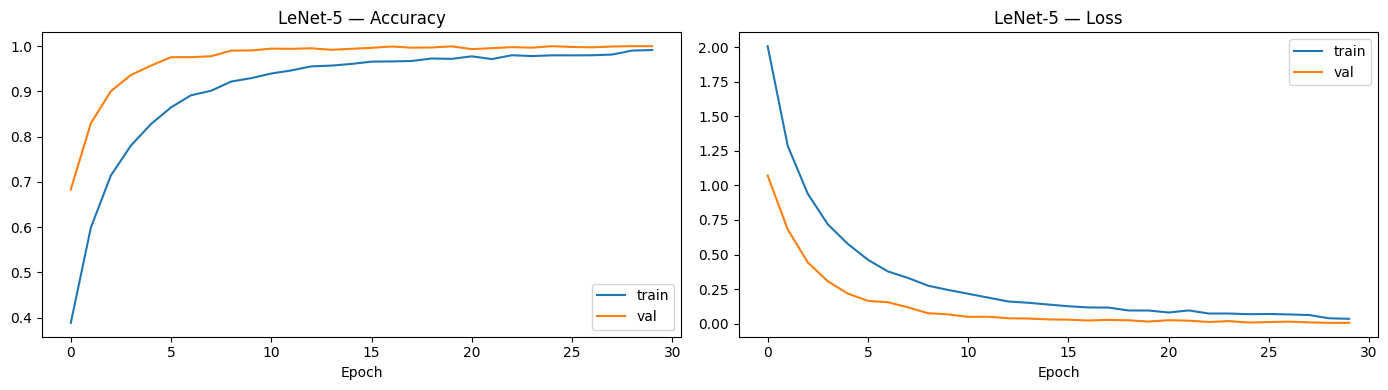


  LeNet-5
  Test Loss: 0.2263  |  Test Accuracy: 95.29%
              precision    recall  f1-score   support

           A       1.00      1.00      1.00       331
           B       1.00      1.00      1.00       432
           C       1.00      1.00      1.00       310
           D       1.00      0.94      0.97       245
           E       0.94      1.00      0.97       498
           F       0.97      1.00      0.99       247
           G       0.99      0.89      0.94       348
           H       1.00      0.98      0.99       436
           I       0.93      1.00      0.96       288
           K       0.95      1.00      0.97       331
           L       1.00      1.00      1.00       209
           M       0.84      0.95      0.89       394
           N       0.91      0.79      0.84       291
           O       1.00      1.00      1.00       246
           P       1.00      1.00      1.00       347
           Q       0.89      1.00      0.94       164
           R       0.69 

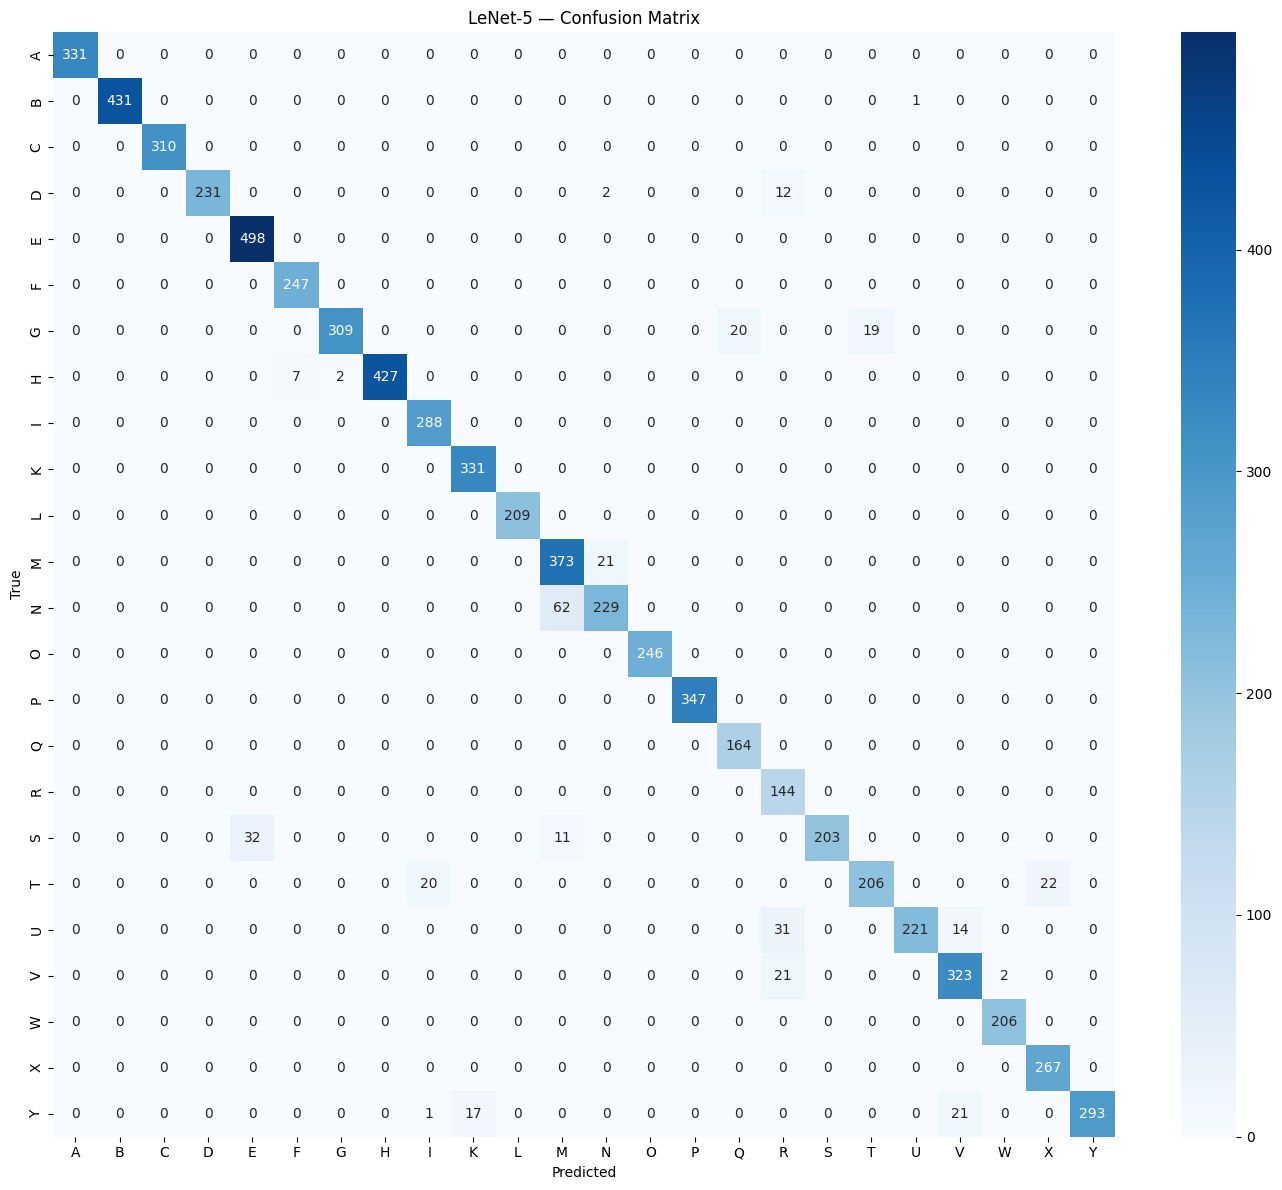

In [12]:
# ── Train ─────────────────────────────────────────────────────────────────────
lenet_cb = [
    callbacks.EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(factor=0.5, patience=3, verbose=1),
    callbacks.ModelCheckpoint(f'{SAVE_DIR}/lenet_sign.h5', save_best_only=True, verbose=1)
]

history_lenet = lenet.fit(
    x_train_lenet, y_train_lenet,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    callbacks=lenet_cb
)

plot_history(history_lenet, 'LeNet-5')
acc_lenet = evaluate_model(lenet, x_test_lenet, y_test_lenet, 'LeNet-5', label_to_letter)

In [13]:
# ── Prepare AlexNet data as a tf.data pipeline (no giant 17 GB array) ────────
# prep_alexnet() would materialise ~17 GB (27k × 227×227×3×float32) → OOM crash.
# Instead we resize on-the-fly per batch using tf.data.

ALEXNET_SIZE  = 227
ALEXNET_BATCH = 32

def make_alexnet_dataset(X, y, training=True, batch_size=ALEXNET_BATCH):
    """Build a tf.data pipeline: resize 28×28 gray → 227×227 RGB per batch."""
    # X shape: (N, 28, 28)  — raw uint8-range floats, NOT yet /255
    def preprocess(img, label):
        img = tf.cast(img, tf.float32) / 255.0          # normalise
        img = tf.expand_dims(img, axis=-1)               # (28,28,1)
        img = tf.image.grayscale_to_rgb(img)             # (28,28,3)
        img = tf.image.resize(img, [ALEXNET_SIZE, ALEXNET_SIZE])  # (227,227,3)
        return img, label

    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if training:
        ds = ds.shuffle(buffer_size=4096, seed=SEED)
    ds = (ds
          .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
          .batch(batch_size)
          .prefetch(tf.data.AUTOTUNE))
    return ds

train_ds_alex = make_alexnet_dataset(X_train_raw, y_train, training=True)
val_size      = int(0.1 * len(X_train_raw))
val_ds_alex   = make_alexnet_dataset(X_train_raw[:val_size], y_train[:val_size], training=False)
test_ds_alex  = make_alexnet_dataset(X_test_raw,  y_test,  training=False)

print(f"AlexNet tf.data pipeline ready — input shape per batch: "
      f"{next(iter(train_ds_alex))[0].shape}")
print("Peak RAM used: only one batch at a time (~{:.1f} MB/batch)".format(
      ALEXNET_BATCH * ALEXNET_SIZE * ALEXNET_SIZE * 3 * 4 / 1e6))


AlexNet tf.data pipeline ready — input shape per batch: (32, 227, 227, 3)
Peak RAM used: only one batch at a time (~19.8 MB/batch)


In [14]:
# ── Build AlexNet ─────────────────────────────────────────────────────────────
alexnet = models.Sequential([
    layers.Input(shape=(227, 227, 3)),

    # Block 1
    layers.Conv2D(96, (11, 11), strides=4, activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((3, 3), strides=2),

    # Block 2
    layers.Conv2D(256, (5, 5), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((3, 3), strides=2),

    # Block 3
    layers.Conv2D(384, (3, 3), padding='same', activation='relu'),

    # Block 4
    layers.Conv2D(384, (3, 3), padding='same', activation='relu'),

    # Block 5
    layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((3, 3), strides=2),

    # Classifier head
    layers.Flatten(),
    layers.Dense(4096, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4096, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax'),
], name='AlexNet')

alexnet.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
alexnet.summary()

Model: "AlexNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 55, 55, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 55, 55, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 27, 27, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 27, 27, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 27, 27, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 13, 13, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 13, 13, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4096)           │    37,752,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 24)             │        98,328 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,381,080 (222.71 MB)

 Trainable params: 58,380,376 (222.70 MB)

 Non-trainable params: 704 (2.75 KB)

Epoch 1/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.6383 - loss: 1.1962
Epoch 1: val_loss improved from None to 0.30069, saving model to /content/asl_models/alexnet_sign.h5



Epoch 1: finished saving model to /content/asl_models/alexnet_sign.h5
858/858 ━━━━━━━━━━━━━━━━━━━━ 71s 71ms/step - accuracy: 0.8579 - loss: 0.4543 - val_accuracy: 0.9213 - val_loss: 0.3007 - learning_rate: 1.0000e-04
Epoch 2/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9952 - loss: 0.0175
Epoch 2: val_loss improved from 0.30069 to 0.07799, saving model to /content/asl_models/alexnet_sign.h5



Epoch 2: finished saving model to /content/asl_models/alexnet_sign.h5
858/858 ━━━━━━━━━━━━━━━━━━━━ 72s 69ms/step - accuracy: 0.9949 - loss: 0.0187 - val_accuracy: 0.9760 - val_loss: 0.0780 - learning_rate: 1.0000e-04
Epoch 3/20
857/858 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9901 - loss: 0.0350
Epoch 3: val_loss improved from 0.07799 to 0.00436, saving model to /content/asl_models/alexnet_sign.h5



Epoch 3: finished saving model to /content/asl_models/alexnet_sign.h5
858/858 ━━━━━━━━━━━━━━━━━━━━ 62s 73ms/step - accuracy: 0.9943 - loss: 0.0204 - val_accuracy: 0.9985 - val_loss: 0.0044 - learning_rate: 1.0000e-04
Epoch 4/20
857/858 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9949 - loss: 0.0199
Epoch 4: val_loss did not improve from 0.00436
858/858 ━━━━━━━━━━━━━━━━━━━━ 46s 54ms/step - accuracy: 0.9940 - loss: 0.0235 - val_accuracy: 0.7071 - val_loss: 1.1207 - learning_rate: 1.0000e-04
Epoch 5/20
857/858 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9963 - loss: 0.0166
Epoch 5: val_loss improved from 0.00436 to 0.00000, saving model to /content/asl_models/alexnet_sign.h5



Epoch 5: finished saving model to /content/asl_models/alexnet_sign.h5
858/858 ━━━━━━━━━━━━━━━━━━━━ 57s 67ms/step - accuracy: 0.9989 - loss: 0.0042 - val_accuracy: 1.0000 - val_loss: 3.1775e-07 - learning_rate: 1.0000e-04
Epoch 6/20
857/858 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9929 - loss: 0.0275
Epoch 6: val_loss did not improve from 0.00000
858/858 ━━━━━━━━━━━━━━━━━━━━ 46s 54ms/step - accuracy: 0.9922 - loss: 0.0304 - val_accuracy: 0.9989 - val_loss: 0.0070 - learning_rate: 1.0000e-04
Epoch 7/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9999 - loss: 5.0294e-04
Epoch 7: val_loss did not improve from 0.00000
858/858 ━━━━━━━━━━━━━━━━━━━━ 45s 53ms/step - accuracy: 0.9998 - loss: 8.6890e-04 - val_accuracy: 1.0000 - val_loss: 1.1738e-06 - learning_rate: 1.0000e-04
Epoch 8/20
857/858 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9995 - loss: 0.0024
Epoch 8: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 8: val_loss did not improve from 0

...


Epoch 13: finished saving model to /content/asl_models/alexnet_sign.h5
858/858 ━━━━━━━━━━━━━━━━━━━━ 63s 74ms/step - accuracy: 1.0000 - loss: 5.9912e-06 - val_accuracy: 1.0000 - val_loss: 5.2503e-08 - learning_rate: 2.5000e-05
Epoch 14/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 1.0000 - loss: 5.8880e-05
Epoch 14: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.

Epoch 14: val_loss improved from 0.00000 to 0.00000, saving model to /content/asl_models/alexnet_sign.h5



Epoch 14: finished saving model to /content/asl_models/alexnet_sign.h5
858/858 ━━━━━━━━━━━━━━━━━━━━ 50s 58ms/step - accuracy: 1.0000 - loss: 3.6524e-05 - val_accuracy: 1.0000 - val_loss: 7.8604e-09 - learning_rate: 2.5000e-05
Epoch 15/20
857/858 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 1.0000 - loss: 9.2554e-06
Epoch 15: val_loss improved from 0.00000 to 0.00000, saving model to /content/asl_models/alexnet_sign.h5



Epoch 15: finished saving model to /content/asl_models/alexnet_sign.h5
858/858 ━━━━━━━━━━━━━━━━━━━━ 63s 73ms/step - accuracy: 1.0000 - loss: 1.2433e-05 - val_accuracy: 1.0000 - val_loss: 5.4719e-09 - learning_rate: 1.2500e-05
Epoch 16/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 1.0000 - loss: 1.4348e-06
Epoch 16: val_loss improved from 0.00000 to 0.00000, saving model to /content/asl_models/alexnet_sign.h5



Epoch 16: finished saving model to /content/asl_models/alexnet_sign.h5
858/858 ━━━━━━━━━━━━━━━━━━━━ 57s 67ms/step - accuracy: 1.0000 - loss: 1.3976e-06 - val_accuracy: 1.0000 - val_loss: 3.6914e-09 - learning_rate: 1.2500e-05
Epoch 17/20
857/858 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 1.0000 - loss: 1.2248e-06
Epoch 17: ReduceLROnPlateau reducing learning rate to 6.24999984211172e-06.

Epoch 17: val_loss improved from 0.00000 to 0.00000, saving model to /content/asl_models/alexnet_sign.h5



Epoch 17: finished saving model to /content/asl_models/alexnet_sign.h5
858/858 ━━━━━━━━━━━━━━━━━━━━ 57s 67ms/step - accuracy: 1.0000 - loss: 1.1601e-06 - val_accuracy: 1.0000 - val_loss: 2.9531e-09 - learning_rate: 1.2500e-05
Epoch 18/20
857/858 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 1.0000 - loss: 9.4887e-06
Epoch 18: val_loss did not improve from 0.00000
858/858 ━━━━━━━━━━━━━━━━━━━━ 47s 55ms/step - accuracy: 1.0000 - loss: 3.0034e-05 - val_accuracy: 1.0000 - val_loss: 6.9919e-09 - learning_rate: 6.2500e-06
Epoch 19/20
857/858 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 1.0000 - loss: 5.8168e-05
Epoch 19: val_loss did not improve from 0.00000
858/858 ━━━━━━━━━━━━━━━━━━━━ 47s 54ms/step - accuracy: 1.0000 - loss: 2.2099e-05 - val_accuracy: 1.0000 - val_loss: 4.7336e-09 - learning_rate: 6.2500e-06
Epoch 20/20
857/858 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 1.0000 - loss: 3.6057e-06
Epoch 20: ReduceLROnPlateau reducing learning rate to 3.12499992105586e-06.

Epoch 20: val_

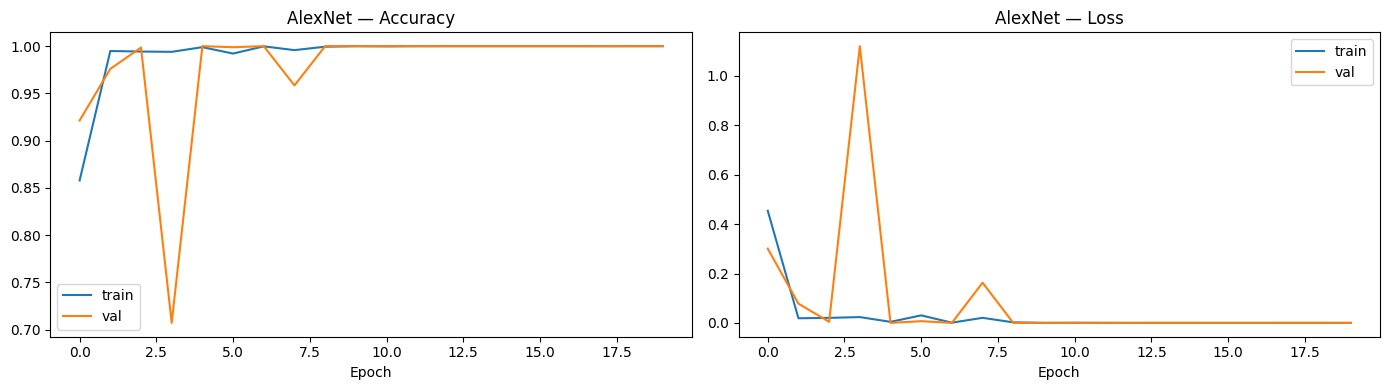


  AlexNet
  Test Loss: 0.0391  |  Test Accuracy: 98.69%
              precision    recall  f1-score   support

           A       1.00      1.00      1.00       331
           B       1.00      1.00      1.00       432
           C       1.00      1.00      1.00       310
           D       1.00      1.00      1.00       245
           E       1.00      1.00      1.00       498
           F       1.00      1.00      1.00       247
           G       0.94      0.94      0.94       348
           H       1.00      0.96      0.98       436
           I       1.00      1.00      1.00       288
           K       0.97      0.97      0.97       331
           L       0.98      1.00      0.99       209
           M       1.00      1.00      1.00       394
           N       1.00      1.00      1.00       291
           O       1.00      1.00      1.00       246
           P       1.00      1.00      1.00       347
           Q       0.89      1.00      0.94       164
           R       1.00 

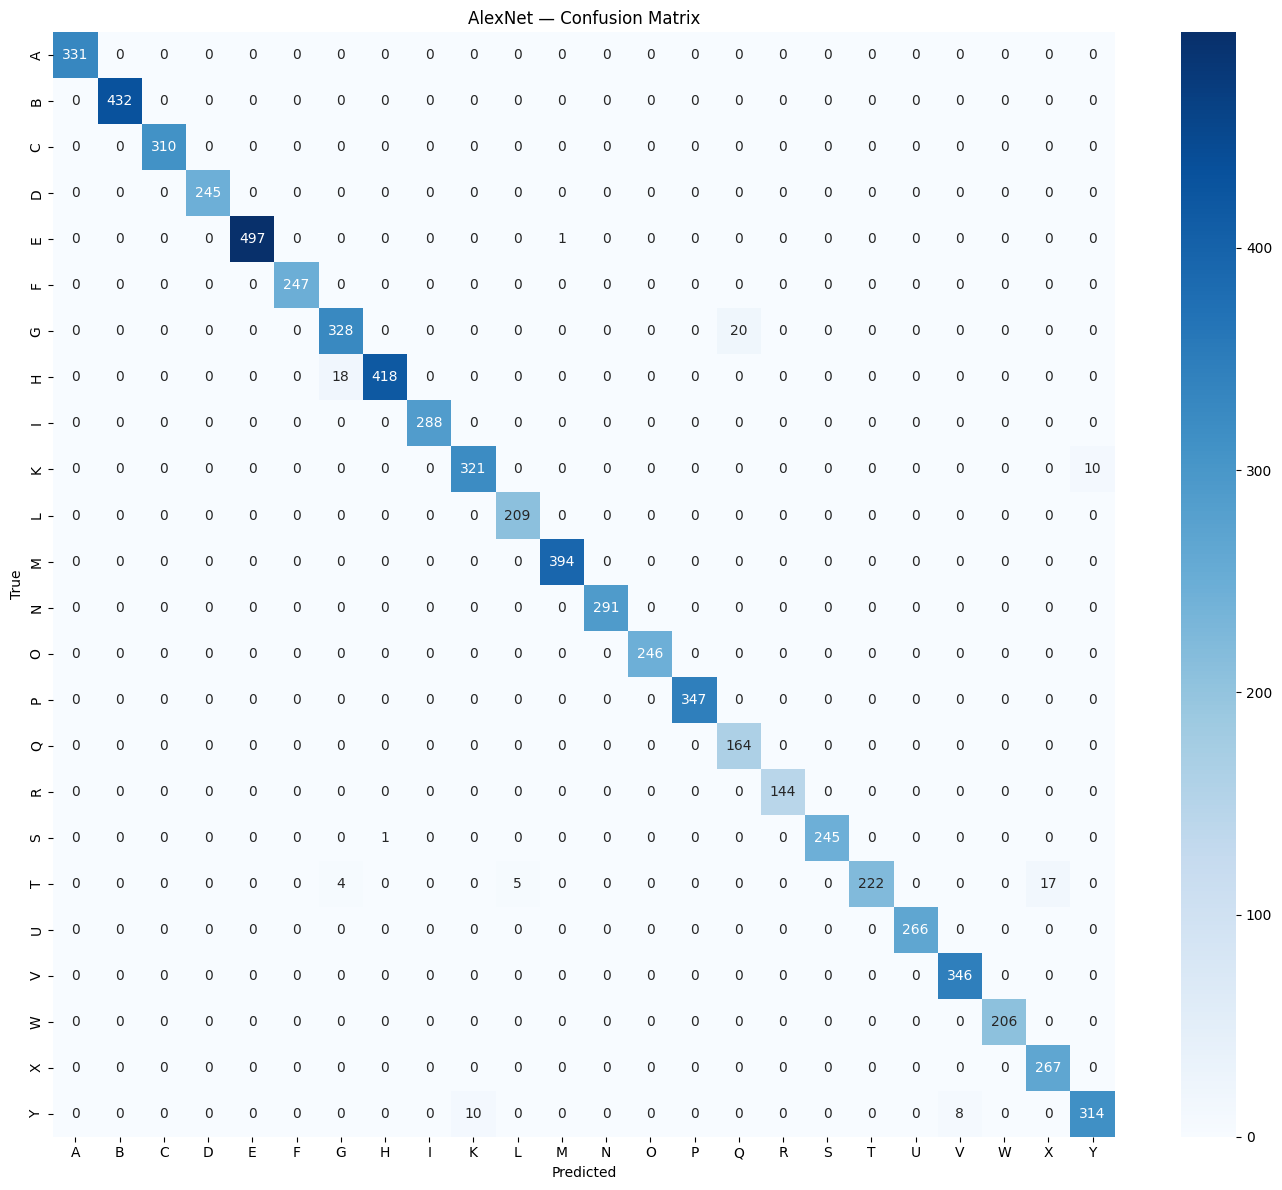

In [15]:
# ── Train AlexNet (using tf.data pipeline) ───────────────────────────────────
alexnet_cb = [
    callbacks.EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(factor=0.5, patience=3, verbose=1),
    callbacks.ModelCheckpoint(f'{SAVE_DIR}/alexnet_sign.h5', save_best_only=True, verbose=1)
]

history_alexnet = alexnet.fit(
    train_ds_alex,
    epochs=20,
    validation_data=val_ds_alex,
    callbacks=alexnet_cb
)

plot_history(history_alexnet, 'AlexNet')
acc_alexnet = evaluate_model(alexnet, test_ds_alex, y_test, 'AlexNet', label_to_letter)


In [16]:
# ── Prepare ResNet50 data as tf.data pipeline (avoids ~17 GB RAM spike) ──
_res_SIZE  = 224
_res_BATCH = 32

def make_res_dataset(X, y, training=True, batch_size=_res_BATCH):
    def preprocess(img, label):
        img = tf.cast(img, tf.float32) / 255.0             # normalise to [0,1]
        img = tf.expand_dims(img, axis=-1)                  # (28,28,1)
        img = tf.image.grayscale_to_rgb(img)                # (28,28,3)
        img = tf.image.resize(img, [_res_SIZE, _res_SIZE])
        img = tf.py_function(func=lambda x: applications.resnet50.preprocess_input(x.numpy().reshape(1,_res_SIZE,_res_SIZE,3)).reshape(_res_SIZE,_res_SIZE,3),
                             inp=[img], Tout=tf.float32)
        img.set_shape([_res_SIZE, _res_SIZE, 3])
        return img, label

    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if training:
        ds = ds.shuffle(buffer_size=4096, seed=SEED)
    return (ds
            .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
            .batch(batch_size)
            .prefetch(tf.data.AUTOTUNE))

val_size_res = int(0.1 * len(X_train_raw))
train_ds_res = make_res_dataset(X_train_raw[:-val_size_res], y_train[:-val_size_res], training=True)
val_ds_res   = make_res_dataset(X_train_raw[-val_size_res:], y_train[-val_size_res:], training=False)
test_ds_res  = make_res_dataset(X_test_raw, y_test, training=False)

print(f"ResNet50 tf.data pipeline ready.")
print(f"  train batches: {len(train_ds_res)}  val batches: {len(val_ds_res)}  test batches: {len(test_ds_res)}")


ResNet50 tf.data pipeline ready.
  train batches: 773  val batches: 86  test batches: 225


In [17]:
# ── Build ResNet50 ────────────────────────────────────────────────────────────
def build_resnet50(num_classes):
    base = applications.ResNet50(weights='imagenet', include_top=False,
                                  input_shape=(224, 224, 3))
    base.trainable = False

    inputs = layers.Input(shape=(224, 224, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, outputs, name='ResNet50_TL'), base

resnet50_model, resnet50_base = build_resnet50(NUM_CLASSES)

resnet50_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
resnet50_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "ResNet50_TL"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 24)             │         6,168 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,118,424 (92.00 MB)

 Trainable params: 530,712 (2.02 MB)

 Non-trainable params: 23,587,712 (89.98 MB)


─── Stage 1: Training classification head (backbone frozen) ───
Epoch 1/10
773/773 ━━━━━━━━━━━━━━━━━━━━ 138s 161ms/step - accuracy: 0.0444 - loss: 3.1849 - val_accuracy: 0.0477 - val_loss: 3.1774 - learning_rate: 0.0010
Epoch 2/10
773/773 ━━━━━━━━━━━━━━━━━━━━ 112s 145ms/step - accuracy: 0.0461 - loss: 3.1758 - val_accuracy: 0.0477 - val_loss: 3.1775 - learning_rate: 0.0010
Epoch 3/10
772/773 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.0472 - loss: 3.1758
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
773/773 ━━━━━━━━━━━━━━━━━━━━ 112s 145ms/step - accuracy: 0.0471 - loss: 3.1757 - val_accuracy: 0.0477 - val_loss: 3.1777 - learning_rate: 0.0010
Epoch 4/10
773/773 ━━━━━━━━━━━━━━━━━━━━ 114s 147ms/step - accuracy: 0.0471 - loss: 3.1755 - val_accuracy: 0.0477 - val_loss: 3.1778 - learning_rate: 5.0000e-04
Epoch 5/10
772/773 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.0473 - loss: 3.1755
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.00025000001

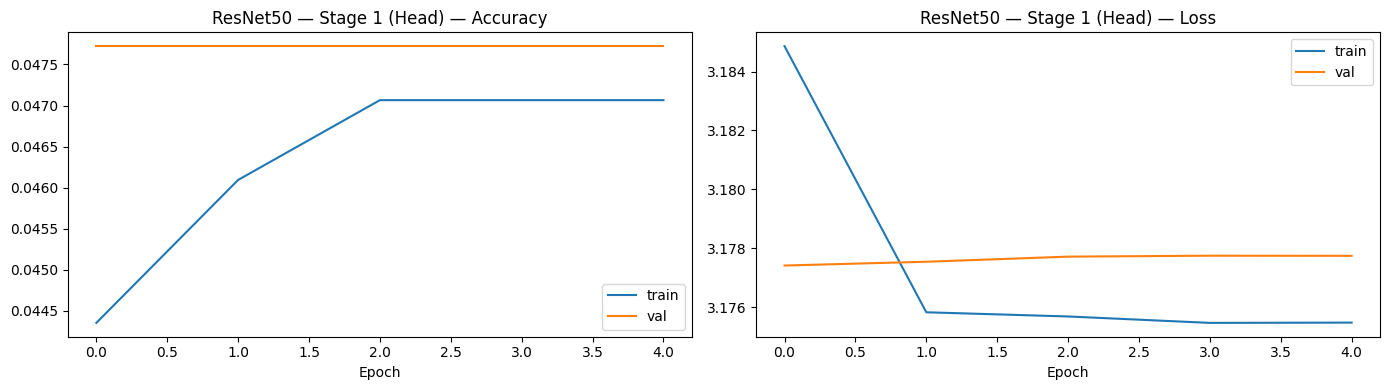

In [18]:
# ── Stage 1: Train head ───────────────────────────────────────────────────────
print("\n─── Stage 1: Training classification head (backbone frozen) ───")
res_cb1 = [
    callbacks.EarlyStopping(patience=4, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(factor=0.5, patience=2, verbose=1),
]

history_res1 = resnet50_model.fit(
    train_ds_res,
    epochs=10,
    validation_data=val_ds_res,
    callbacks=res_cb1
)
plot_history(history_res1, 'ResNet50 — Stage 1 (Head)')



─── Stage 2: Fine-tuning (unfreezing last ResNet block) ───
Epoch 1/10
773/773 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.3709 - loss: 2.2875
Epoch 1: val_loss improved from None to 0.77275, saving model to /content/asl_models/resnet50_sign.h5



Epoch 1: finished saving model to /content/asl_models/resnet50_sign.h5
773/773 ━━━━━━━━━━━━━━━━━━━━ 179s 206ms/step - accuracy: 0.5820 - loss: 1.6025 - val_accuracy: 0.7956 - val_loss: 0.7727
Epoch 2/10
772/773 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.8861 - loss: 0.5080
Epoch 2: val_loss improved from 0.77275 to 0.20236, saving model to /content/asl_models/resnet50_sign.h5



Epoch 2: finished saving model to /content/asl_models/resnet50_sign.h5
773/773 ━━━━━━━━━━━━━━━━━━━━ 149s 192ms/step - accuracy: 0.9155 - loss: 0.3916 - val_accuracy: 0.9446 - val_loss: 0.2024
Epoch 3/10
772/773 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.9632 - loss: 0.1921
Epoch 3: val_loss improved from 0.20236 to 0.08758, saving model to /content/asl_models/resnet50_sign.h5



Epoch 3: finished saving model to /content/asl_models/resnet50_sign.h5
773/773 ━━━━━━━━━━━━━━━━━━━━ 150s 193ms/step - accuracy: 0.9691 - loss: 0.1611 - val_accuracy: 0.9792 - val_loss: 0.0876
Epoch 4/10
772/773 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.9765 - loss: 0.1135
Epoch 4: val_loss improved from 0.08758 to 0.05027, saving model to /content/asl_models/resnet50_sign.h5



Epoch 4: finished saving model to /content/asl_models/resnet50_sign.h5
773/773 ━━━━━━━━━━━━━━━━━━━━ 152s 196ms/step - accuracy: 0.9787 - loss: 0.1043 - val_accuracy: 0.9858 - val_loss: 0.0503
Epoch 5/10
772/773 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.9852 - loss: 0.0736
Epoch 5: val_loss did not improve from 0.05027
773/773 ━━━━━━━━━━━━━━━━━━━━ 143s 185ms/step - accuracy: 0.9858 - loss: 0.0716 - val_accuracy: 0.9144 - val_loss: 0.2861
Epoch 6/10
772/773 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.9835 - loss: 0.0746
Epoch 6: val_loss did not improve from 0.05027
773/773 ━━━━━━━━━━━━━━━━━━━━ 141s 182ms/step - accuracy: 0.9853 - loss: 0.0666 - val_accuracy: 0.9581 - val_loss: 0.1260
Epoch 7/10
772/773 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.9824 - loss: 0.0722
Epoch 7: val_loss did not improve from 0.05027
773/773 ━━━━━━━━━━━━━━━━━━━━ 144s 186ms/step - accuracy: 0.9854 - loss: 0.0618 - val_accuracy: 0.9556 - val_loss: 0.1381
Epoch 8/10
772/773 ━━━━━━━━━━━━━━━━━━━━

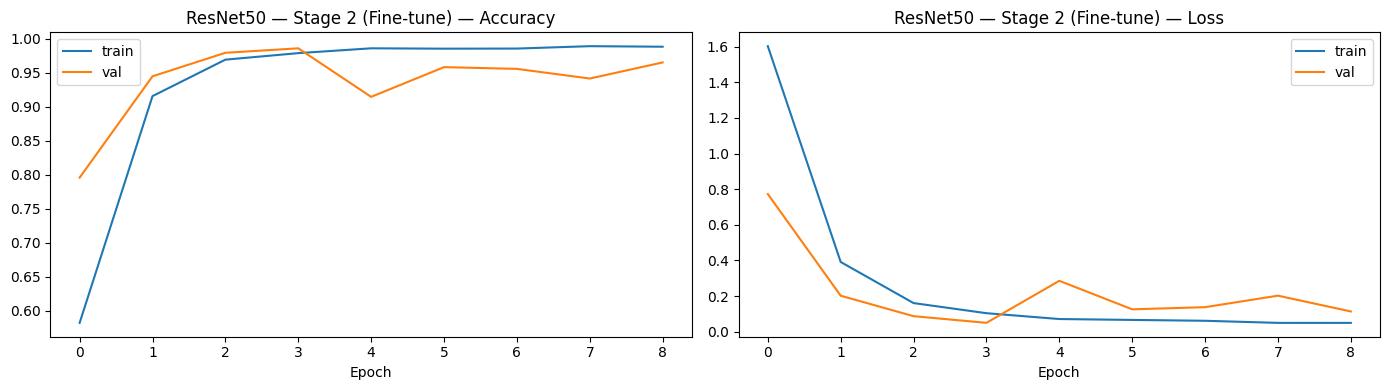


  ResNet50
  Test Loss: 0.3893  |  Test Accuracy: 88.59%
              precision    recall  f1-score   support

           A       1.00      0.89      0.94       331
           B       0.98      0.94      0.96       432
           C       1.00      1.00      1.00       310
           D       0.90      0.77      0.83       245
           E       0.93      0.98      0.95       498
           F       1.00      0.99      1.00       247
           G       0.83      0.84      0.83       348
           H       0.77      0.88      0.82       436
           I       1.00      0.93      0.96       288
           K       0.64      0.89      0.74       331
           L       1.00      1.00      1.00       209
           M       0.97      0.79      0.87       394
           N       0.87      0.89      0.88       291
           O       0.87      0.93      0.90       246
           P       0.89      1.00      0.94       347
           Q       1.00      0.98      0.99       164
           R       0.49

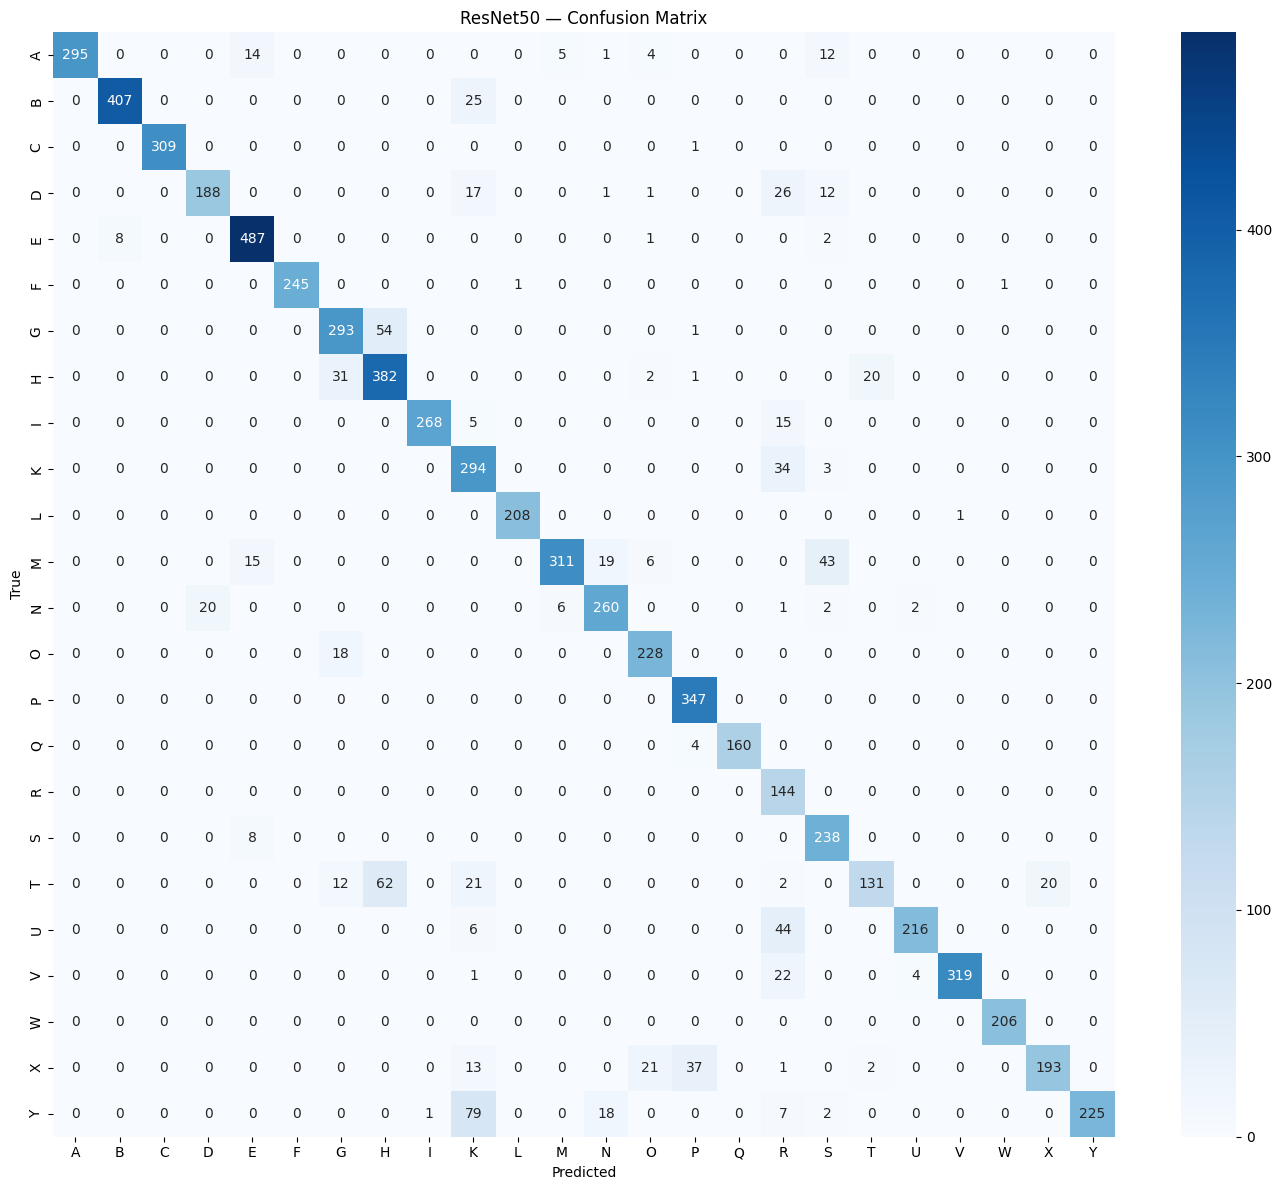

In [19]:
# ── Stage 2: Fine-tune last block ─────────────────────────────────────────────
print("\n─── Stage 2: Fine-tuning (unfreezing last ResNet block) ───")
resnet50_base.trainable = True
for layer in resnet50_base.layers[:-30]:
    layer.trainable = False

resnet50_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

res_cb2 = [
    callbacks.EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    callbacks.ModelCheckpoint(f'{SAVE_DIR}/resnet50_sign.h5', save_best_only=True, verbose=1)
]

history_res2 = resnet50_model.fit(
    train_ds_res,
    epochs=10,
    validation_data=val_ds_res,
    callbacks=res_cb2
)
plot_history(history_res2, 'ResNet50 — Stage 2 (Fine-tune)')
acc_resnet = evaluate_model(resnet50_model, test_ds_res, y_test, 'ResNet50', label_to_letter)


In [20]:
# ── Prepare VGG16 data as tf.data pipeline (avoids ~17 GB RAM spike) ──
_vgg_SIZE  = 224
_vgg_BATCH = 32

def make_vgg_dataset(X, y, training=True, batch_size=_vgg_BATCH):
    def preprocess(img, label):
        img = tf.cast(img, tf.float32) / 255.0             # normalise to [0,1]
        img = tf.expand_dims(img, axis=-1)                  # (28,28,1)
        img = tf.image.grayscale_to_rgb(img)                # (28,28,3)
        img = tf.image.resize(img, [_vgg_SIZE, _vgg_SIZE])
        img = tf.py_function(func=lambda x: applications.vgg16.preprocess_input(x.numpy().reshape(1,_vgg_SIZE,_vgg_SIZE,3)).reshape(_vgg_SIZE,_vgg_SIZE,3),
                             inp=[img], Tout=tf.float32)
        img.set_shape([_vgg_SIZE, _vgg_SIZE, 3])
        return img, label

    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if training:
        ds = ds.shuffle(buffer_size=4096, seed=SEED)
    return (ds
            .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
            .batch(batch_size)
            .prefetch(tf.data.AUTOTUNE))

val_size_vgg = int(0.1 * len(X_train_raw))
train_ds_vgg = make_vgg_dataset(X_train_raw[:-val_size_vgg], y_train[:-val_size_vgg], training=True)
val_ds_vgg   = make_vgg_dataset(X_train_raw[-val_size_vgg:], y_train[-val_size_vgg:], training=False)
test_ds_vgg  = make_vgg_dataset(X_test_raw, y_test, training=False)

print(f"VGG16 tf.data pipeline ready.")
print(f"  train batches: {len(train_ds_vgg)}  val batches: {len(val_ds_vgg)}  test batches: {len(test_ds_vgg)}")


VGG16 tf.data pipeline ready.
  train batches: 773  val batches: 86  test batches: 225


In [21]:
# ── Build VGG16 ───────────────────────────────────────────────────────────────
def build_vgg16(num_classes):
    base = applications.VGG16(weights='imagenet', include_top=False,
                               input_shape=(224, 224, 3))
    base.trainable = False

    inputs = layers.Input(shape=(224, 224, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, outputs, name='VGG16_TL'), base

vgg16_model, vgg16_base = build_vgg16(NUM_CLASSES)

vgg16_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
vgg16_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "VGG16_TL"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 24)             │         6,168 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,114,840 (57.66 MB)

 Trainable params: 400,152 (1.53 MB)

 Non-trainable params: 14,714,688 (56.13 MB)


─── Stage 1: Training classification head (backbone frozen) ───
Epoch 1/10
773/773 ━━━━━━━━━━━━━━━━━━━━ 225s 269ms/step - accuracy: 0.0413 - loss: 3.2023 - val_accuracy: 0.0386 - val_loss: 3.1800 - learning_rate: 0.0010
Epoch 2/10
773/773 ━━━━━━━━━━━━━━━━━━━━ 189s 245ms/step - accuracy: 0.0452 - loss: 3.1783 - val_accuracy: 0.0412 - val_loss: 3.1782 - learning_rate: 0.0010
Epoch 3/10
773/773 ━━━━━━━━━━━━━━━━━━━━ 193s 250ms/step - accuracy: 0.0429 - loss: 3.1781 - val_accuracy: 0.0477 - val_loss: 3.1784 - learning_rate: 0.0010
Epoch 4/10
773/773 ━━━━━━━━━━━━━━━━━━━━ 192s 248ms/step - accuracy: 0.0457 - loss: 3.1762 - val_accuracy: 0.0477 - val_loss: 3.1779 - learning_rate: 0.0010
Epoch 5/10
773/773 ━━━━━━━━━━━━━━━━━━━━ 192s 248ms/step - accuracy: 0.0471 - loss: 3.1757 - val_accuracy: 0.0477 - val_loss: 3.1778 - learning_rate: 0.0010
Epoch 6/10
773/773 ━━━━━━━━━━━━━━━━━━━━ 190s 246ms/step - accuracy: 0.0465 - loss: 3.1756 - val_accuracy: 0.0477 - val_loss: 3.1779 - learning_rate: 0.0010

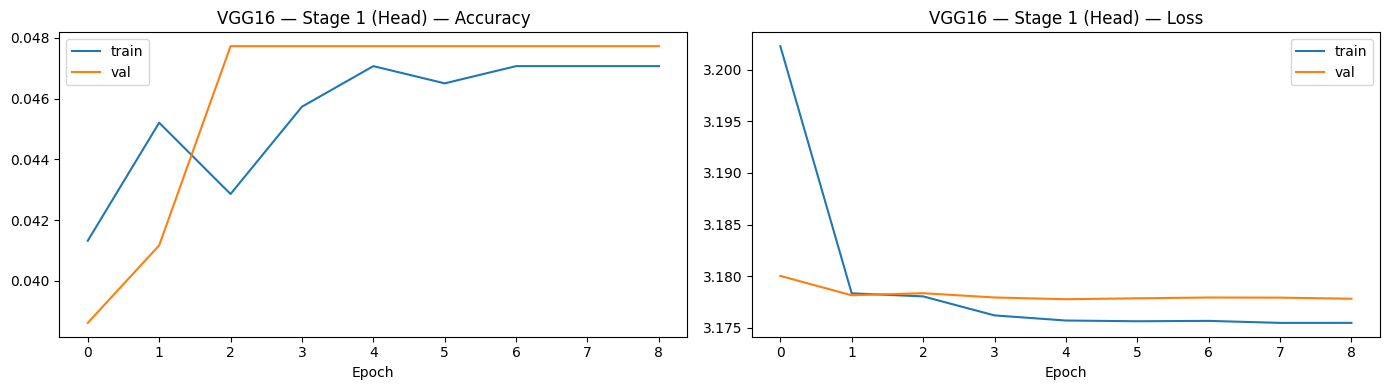

In [22]:
# ── Stage 1: Train head ───────────────────────────────────────────────────────
print("\n─── Stage 1: Training classification head (backbone frozen) ───")
vgg_cb1 = [
    callbacks.EarlyStopping(patience=4, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(factor=0.5, patience=2, verbose=1),
]

history_vgg1 = vgg16_model.fit(
    train_ds_vgg,
    epochs=10,
    validation_data=val_ds_vgg,
    callbacks=vgg_cb1
)
plot_history(history_vgg1, 'VGG16 — Stage 1 (Head)')



─── Stage 2: Fine-tuning (unfreezing VGG16 block5) ───
Epoch 1/10
773/773 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.0476 - loss: 3.1758
Epoch 1: val_loss improved from None to 3.17778, saving model to /content/asl_models/vgg16_sign.h5



Epoch 1: finished saving model to /content/asl_models/vgg16_sign.h5
773/773 ━━━━━━━━━━━━━━━━━━━━ 226s 283ms/step - accuracy: 0.0471 - loss: 3.1753 - val_accuracy: 0.0477 - val_loss: 3.1778
Epoch 2/10
773/773 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - accuracy: 0.0488 - loss: 3.1755
Epoch 2: val_loss improved from 3.17778 to 3.17777, saving model to /content/asl_models/vgg16_sign.h5



Epoch 2: finished saving model to /content/asl_models/vgg16_sign.h5
773/773 ━━━━━━━━━━━━━━━━━━━━ 216s 279ms/step - accuracy: 0.0471 - loss: 3.1753 - val_accuracy: 0.0477 - val_loss: 3.1778
Epoch 3/10
773/773 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - accuracy: 0.0475 - loss: 3.1760
Epoch 3: val_loss improved from 3.17777 to 3.17777, saving model to /content/asl_models/vgg16_sign.h5



Epoch 3: finished saving model to /content/asl_models/vgg16_sign.h5
773/773 ━━━━━━━━━━━━━━━━━━━━ 215s 279ms/step - accuracy: 0.0471 - loss: 3.1753 - val_accuracy: 0.0477 - val_loss: 3.1778
Epoch 4/10
773/773 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step - accuracy: 0.0473 - loss: 3.1761
Epoch 4: val_loss improved from 3.17777 to 3.17777, saving model to /content/asl_models/vgg16_sign.h5



Epoch 4: finished saving model to /content/asl_models/vgg16_sign.h5
773/773 ━━━━━━━━━━━━━━━━━━━━ 215s 278ms/step - accuracy: 0.0471 - loss: 3.1753 - val_accuracy: 0.0477 - val_loss: 3.1778
Epoch 5/10
773/773 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step - accuracy: 0.0486 - loss: 3.1762
Epoch 5: val_loss improved from 3.17777 to 3.17777, saving model to /content/asl_models/vgg16_sign.h5


...


Epoch 6: finished saving model to /content/asl_models/vgg16_sign.h5
773/773 ━━━━━━━━━━━━━━━━━━━━ 216s 280ms/step - accuracy: 0.0471 - loss: 3.1753 - val_accuracy: 0.0477 - val_loss: 3.1778
Epoch 7/10
773/773 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - accuracy: 0.0476 - loss: 3.1757
Epoch 7: val_loss improved from 3.17777 to 3.17777, saving model to /content/asl_models/vgg16_sign.h5



Epoch 7: finished saving model to /content/asl_models/vgg16_sign.h5
773/773 ━━━━━━━━━━━━━━━━━━━━ 217s 281ms/step - accuracy: 0.0471 - loss: 3.1753 - val_accuracy: 0.0477 - val_loss: 3.1778
Epoch 8/10
773/773 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - accuracy: 0.0462 - loss: 3.1755
Epoch 8: val_loss improved from 3.17777 to 3.17777, saving model to /content/asl_models/vgg16_sign.h5



Epoch 8: finished saving model to /content/asl_models/vgg16_sign.h5
773/773 ━━━━━━━━━━━━━━━━━━━━ 215s 278ms/step - accuracy: 0.0471 - loss: 3.1753 - val_accuracy: 0.0477 - val_loss: 3.1778
Epoch 9/10
773/773 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step - accuracy: 0.0473 - loss: 3.1756
Epoch 9: val_loss improved from 3.17777 to 3.17777, saving model to /content/asl_models/vgg16_sign.h5



Epoch 9: finished saving model to /content/asl_models/vgg16_sign.h5
773/773 ━━━━━━━━━━━━━━━━━━━━ 217s 281ms/step - accuracy: 0.0471 - loss: 3.1753 - val_accuracy: 0.0477 - val_loss: 3.1778
Epoch 10/10
773/773 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - accuracy: 0.0478 - loss: 3.1761
Epoch 10: val_loss improved from 3.17777 to 3.17776, saving model to /content/asl_models/vgg16_sign.h5



Epoch 10: finished saving model to /content/asl_models/vgg16_sign.h5
773/773 ━━━━━━━━━━━━━━━━━━━━ 219s 283ms/step - accuracy: 0.0471 - loss: 3.1753 - val_accuracy: 0.0477 - val_loss: 3.1778
Restoring model weights from the end of the best epoch: 10.


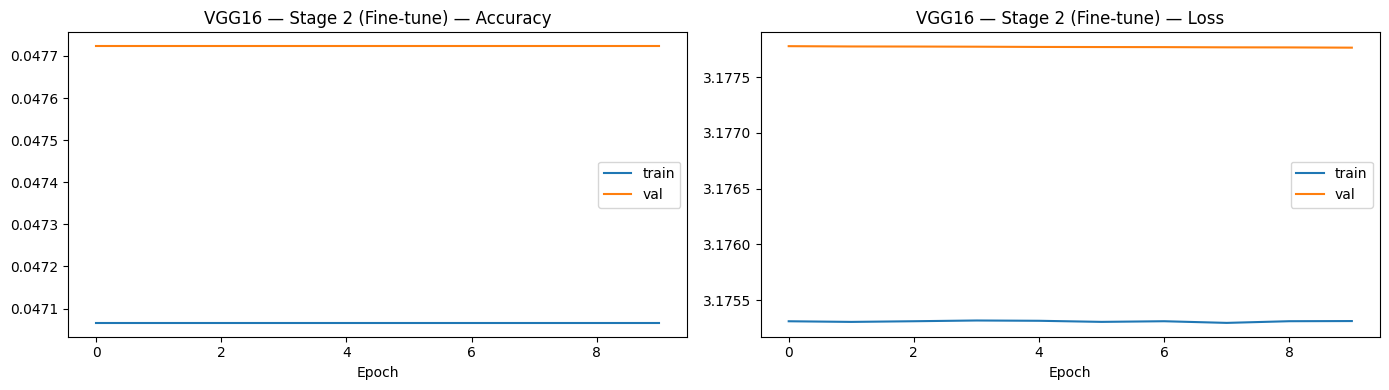


  VGG16
  Test Loss: 3.2013  |  Test Accuracy: 2.01%
              precision    recall  f1-score   support

           A       0.00      0.00      0.00       331
           B       0.00      0.00      0.00       432
           C       0.00      0.00      0.00       310
           D       0.00      0.00      0.00       245
           E       0.00      0.00      0.00       498
           F       0.00      0.00      0.00       247
           G       0.00      0.00      0.00       348
           H       0.00      0.00      0.00       436
           I       0.00      0.00      0.00       288
           K       0.00      0.00      0.00       331
           L       0.00      0.00      0.00       209
           M       0.00      0.00      0.00       394
           N       0.00      0.00      0.00       291
           O       0.00      0.00      0.00       246
           P       0.00      0.00      0.00       347
           Q       0.00      0.00      0.00       164
           R       0.02    

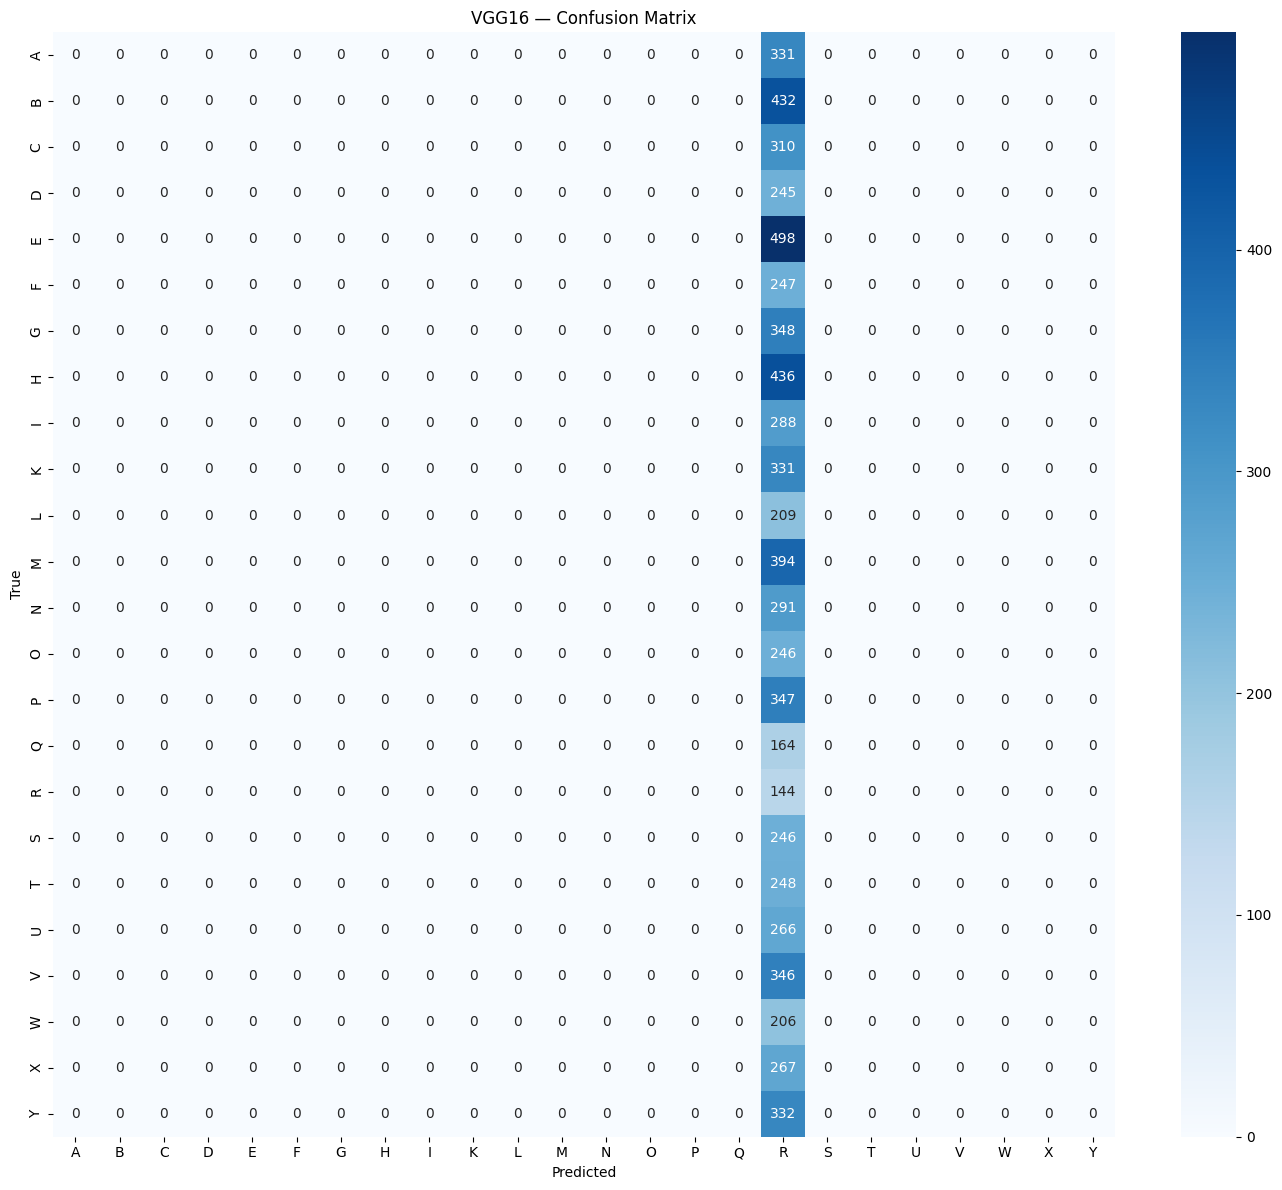

In [23]:
# ── Stage 2: Fine-tune block5 ─────────────────────────────────────────────────
print("\n─── Stage 2: Fine-tuning (unfreezing VGG16 block5) ───")
vgg16_base.trainable = True
for layer in vgg16_base.layers:
    if not layer.name.startswith('block5'):
        layer.trainable = False

vgg16_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

vgg_cb2 = [
    callbacks.EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    callbacks.ModelCheckpoint(f'{SAVE_DIR}/vgg16_sign.h5', save_best_only=True, verbose=1)
]

history_vgg2 = vgg16_model.fit(
    train_ds_vgg,
    epochs=10,
    validation_data=val_ds_vgg,
    callbacks=vgg_cb2
)
plot_history(history_vgg2, 'VGG16 — Stage 2 (Fine-tune)')
acc_vgg = evaluate_model(vgg16_model, test_ds_vgg, y_test, 'VGG16', label_to_letter)


In [24]:
# ── Prepare MobileNetV2 data as tf.data pipeline (avoids ~3 GB RAM spike) ────
_mob_SIZE  = 96
_mob_BATCH = 64

def make_mob_dataset(X, y, training=True, batch_size=_mob_BATCH):
    def preprocess(img, label):
        img = tf.cast(img, tf.float32)                       # keep [0,255]
        img = tf.expand_dims(img, axis=-1)                   # (28,28,1)
        img = tf.image.grayscale_to_rgb(img)                 # (28,28,3)
        img = tf.image.resize(img, [_mob_SIZE, _mob_SIZE])   # (96,96,3)
        # MobileNetV2 preprocess_input: [0,255] → [-1,1]
        img = (img / 127.5) - 1.0
        return img, label

    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if training:
        ds = ds.shuffle(buffer_size=4096, seed=SEED)
    return (ds
            .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
            .batch(batch_size)
            .prefetch(tf.data.AUTOTUNE))

val_size_mob  = int(0.1 * len(X_train_raw))
train_ds_mob  = make_mob_dataset(X_train_raw[:-val_size_mob], y_train[:-val_size_mob], training=True)
val_ds_mob    = make_mob_dataset(X_train_raw[-val_size_mob:], y_train[-val_size_mob:], training=False)
test_ds_mob   = make_mob_dataset(X_test_raw, y_test, training=False)

print(f"MobileNetV2 tf.data pipeline ready.")
print(f"  train batches: {len(train_ds_mob)}  val: {len(val_ds_mob)}  test: {len(test_ds_mob)}")


MobileNetV2 tf.data pipeline ready.
  train batches: 387  val: 43  test: 113


In [25]:
# ── Build MobileNetV2 ─────────────────────────────────────────────────────────
def build_mobilenetv2(num_classes):
    base = applications.MobileNetV2(weights='imagenet', include_top=False,
                                     input_shape=(96, 96, 3))
    base.trainable = False

    inputs = layers.Input(shape=(96, 96, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, outputs, name='MobileNetV2_TL'), base

mobilenet_model, mobilenet_base = build_mobilenetv2(NUM_CLASSES)

mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_TL"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 24)             │         6,168 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,592,088 (9.89 MB)

 Trainable params: 334,104 (1.27 MB)

 Non-trainable params: 2,257,984 (8.61 MB)


─── Stage 1: Training classification head ───
Epoch 1/15
387/387 ━━━━━━━━━━━━━━━━━━━━ 49s 84ms/step - accuracy: 0.9036 - loss: 0.3423 - val_accuracy: 0.9945 - val_loss: 0.0263 - learning_rate: 0.0010
Epoch 2/15
387/387 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9912 - loss: 0.0376 - val_accuracy: 0.9985 - val_loss: 0.0099 - learning_rate: 0.0010
Epoch 3/15
387/387 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9956 - loss: 0.0184 - val_accuracy: 0.9996 - val_loss: 0.0027 - learning_rate: 0.0010
Epoch 4/15
387/387 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9966 - loss: 0.0139 - val_accuracy: 0.9993 - val_loss: 0.0032 - learning_rate: 0.0010
Epoch 5/15
387/387 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9971 - loss: 0.0117 - val_accuracy: 0.9993 - val_loss: 0.0037 - learning_rate: 0.0010
Epoch 6/15
387/387 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9968 - loss: 0.0111 - val_accuracy: 0.9996 - val_loss: 0.0018 - learning_rate: 0.0010
Epoch 7/15
387/387 ━━━━━━━━━━━━━━

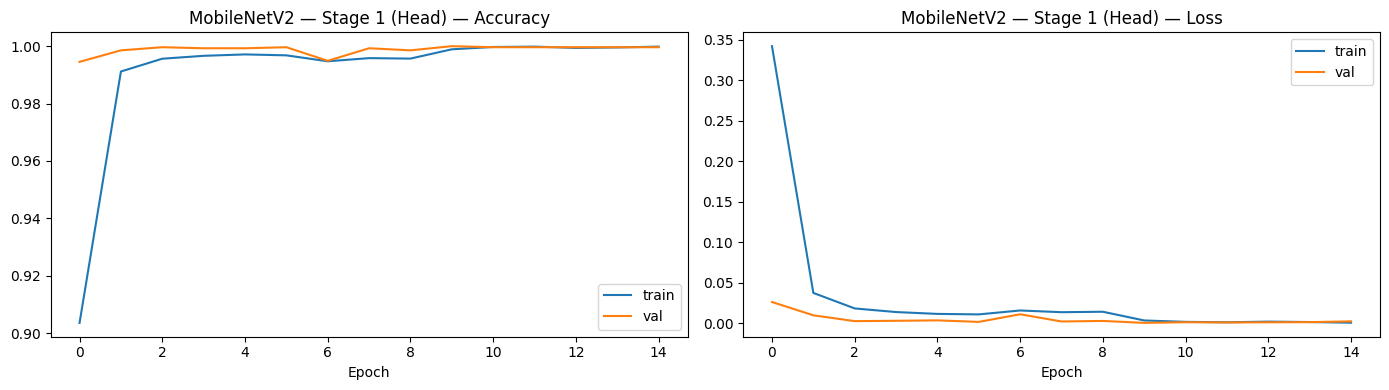

In [26]:
# ── Stage 1: Train head ───────────────────────────────────────────────────────
print("\n─── Stage 1: Training classification head ───")
mob_cb1 = [
    callbacks.EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(factor=0.5, patience=3, verbose=1),
]

history_mob1 = mobilenet_model.fit(
    train_ds_mob,
    epochs=15,
    validation_data=val_ds_mob,
    callbacks=mob_cb1
)
plot_history(history_mob1, 'MobileNetV2 — Stage 1 (Head)')



─── Stage 2: Fine-tuning ───
Epoch 1/15
387/387 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7263 - loss: 1.8923
Epoch 1: val_loss improved from None to 0.00566, saving model to /content/asl_models/mobilenetv2_sign.h5



Epoch 1: finished saving model to /content/asl_models/mobilenetv2_sign.h5
387/387 ━━━━━━━━━━━━━━━━━━━━ 40s 62ms/step - accuracy: 0.8410 - loss: 0.9059 - val_accuracy: 0.9985 - val_loss: 0.0057
Epoch 2/15
384/387 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9635 - loss: 0.1201
Epoch 2: val_loss improved from 0.00566 to 0.00457, saving model to /content/asl_models/mobilenetv2_sign.h5



Epoch 2: finished saving model to /content/asl_models/mobilenetv2_sign.h5
387/387 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9706 - loss: 0.0944 - val_accuracy: 0.9985 - val_loss: 0.0046
Epoch 3/15
386/387 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9854 - loss: 0.0469
Epoch 3: val_loss improved from 0.00457 to 0.00429, saving model to /content/asl_models/mobilenetv2_sign.h5



Epoch 3: finished saving model to /content/asl_models/mobilenetv2_sign.h5
387/387 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9863 - loss: 0.0429 - val_accuracy: 0.9985 - val_loss: 0.0043
Epoch 4/15
386/387 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9925 - loss: 0.0226
Epoch 4: val_loss improved from 0.00429 to 0.00268, saving model to /content/asl_models/mobilenetv2_sign.h5



Epoch 4: finished saving model to /content/asl_models/mobilenetv2_sign.h5
387/387 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9926 - loss: 0.0234 - val_accuracy: 0.9993 - val_loss: 0.0027
Epoch 5/15
385/387 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9937 - loss: 0.0205
Epoch 5: val_loss improved from 0.00268 to 0.00196, saving model to /content/asl_models/mobilenetv2_sign.h5


...


Epoch 9: finished saving model to /content/asl_models/mobilenetv2_sign.h5
387/387 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9983 - loss: 0.0053 - val_accuracy: 0.9996 - val_loss: 6.7648e-04
Epoch 10/15
387/387 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9985 - loss: 0.0045
Epoch 10: val_loss improved from 0.00068 to 0.00047, saving model to /content/asl_models/mobilenetv2_sign.h5



Epoch 10: finished saving model to /content/asl_models/mobilenetv2_sign.h5
387/387 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9987 - loss: 0.0042 - val_accuracy: 0.9996 - val_loss: 4.7320e-04
Epoch 11/15
385/387 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9984 - loss: 0.0054
Epoch 11: val_loss improved from 0.00047 to 0.00023, saving model to /content/asl_models/mobilenetv2_sign.h5



Epoch 11: finished saving model to /content/asl_models/mobilenetv2_sign.h5
387/387 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.9985 - loss: 0.0044 - val_accuracy: 1.0000 - val_loss: 2.2519e-04
Epoch 12/15
385/387 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9988 - loss: 0.0030
Epoch 12: val_loss improved from 0.00023 to 0.00006, saving model to /content/asl_models/mobilenetv2_sign.h5



Epoch 12: finished saving model to /content/asl_models/mobilenetv2_sign.h5
387/387 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.9990 - loss: 0.0029 - val_accuracy: 1.0000 - val_loss: 5.5021e-05
Epoch 13/15
387/387 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9989 - loss: 0.0032
Epoch 13: val_loss did not improve from 0.00006
387/387 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9988 - loss: 0.0033 - val_accuracy: 1.0000 - val_loss: 1.6607e-04
Epoch 14/15
385/387 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9990 - loss: 0.0025
Epoch 14: val_loss did not improve from 0.00006
387/387 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9991 - loss: 0.0028 - val_accuracy: 1.0000 - val_loss: 2.1799e-04
Epoch 15/15
384/387 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9994 - loss: 0.0022
Epoch 15: val_loss improved from 0.00006 to 0.00002, saving model to /content/asl_models/mobilenetv2_sign.h5



Epoch 15: finished saving model to /content/asl_models/mobilenetv2_sign.h5
387/387 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9995 - loss: 0.0019 - val_accuracy: 1.0000 - val_loss: 2.0922e-05
Restoring model weights from the end of the best epoch: 15.


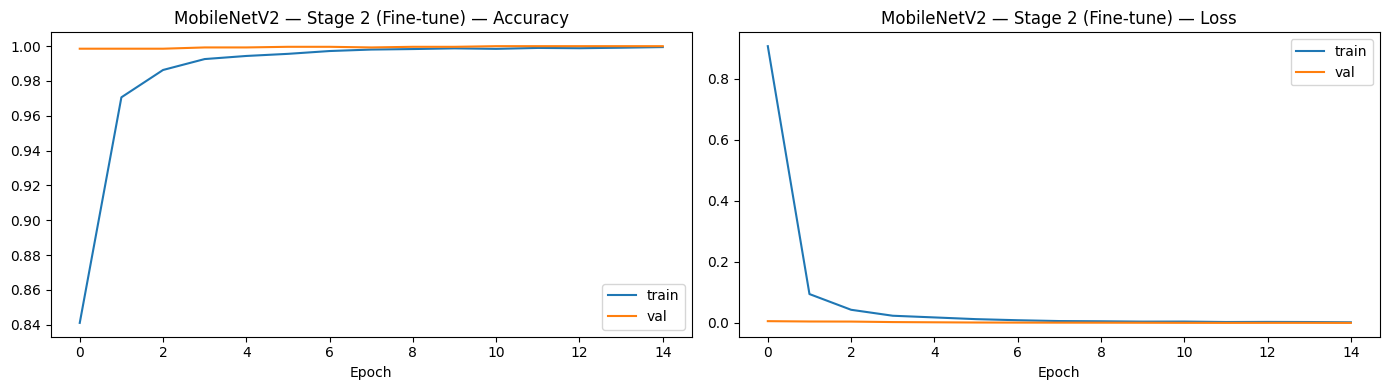


  MobileNetV2
  Test Loss: 0.0138  |  Test Accuracy: 99.50%
              precision    recall  f1-score   support

           A       1.00      1.00      1.00       331
           B       1.00      1.00      1.00       432
           C       1.00      0.97      0.98       310
           D       1.00      1.00      1.00       245
           E       1.00      1.00      1.00       498
           F       1.00      1.00      1.00       247
           G       1.00      1.00      1.00       348
           H       1.00      1.00      1.00       436
           I       1.00      1.00      1.00       288
           K       0.99      0.99      0.99       331
           L       1.00      1.00      1.00       209
           M       0.96      1.00      0.98       394
           N       1.00      0.97      0.98       291
           O       0.96      1.00      0.98       246
           P       0.99      1.00      1.00       347
           Q       1.00      1.00      1.00       164
           R       0

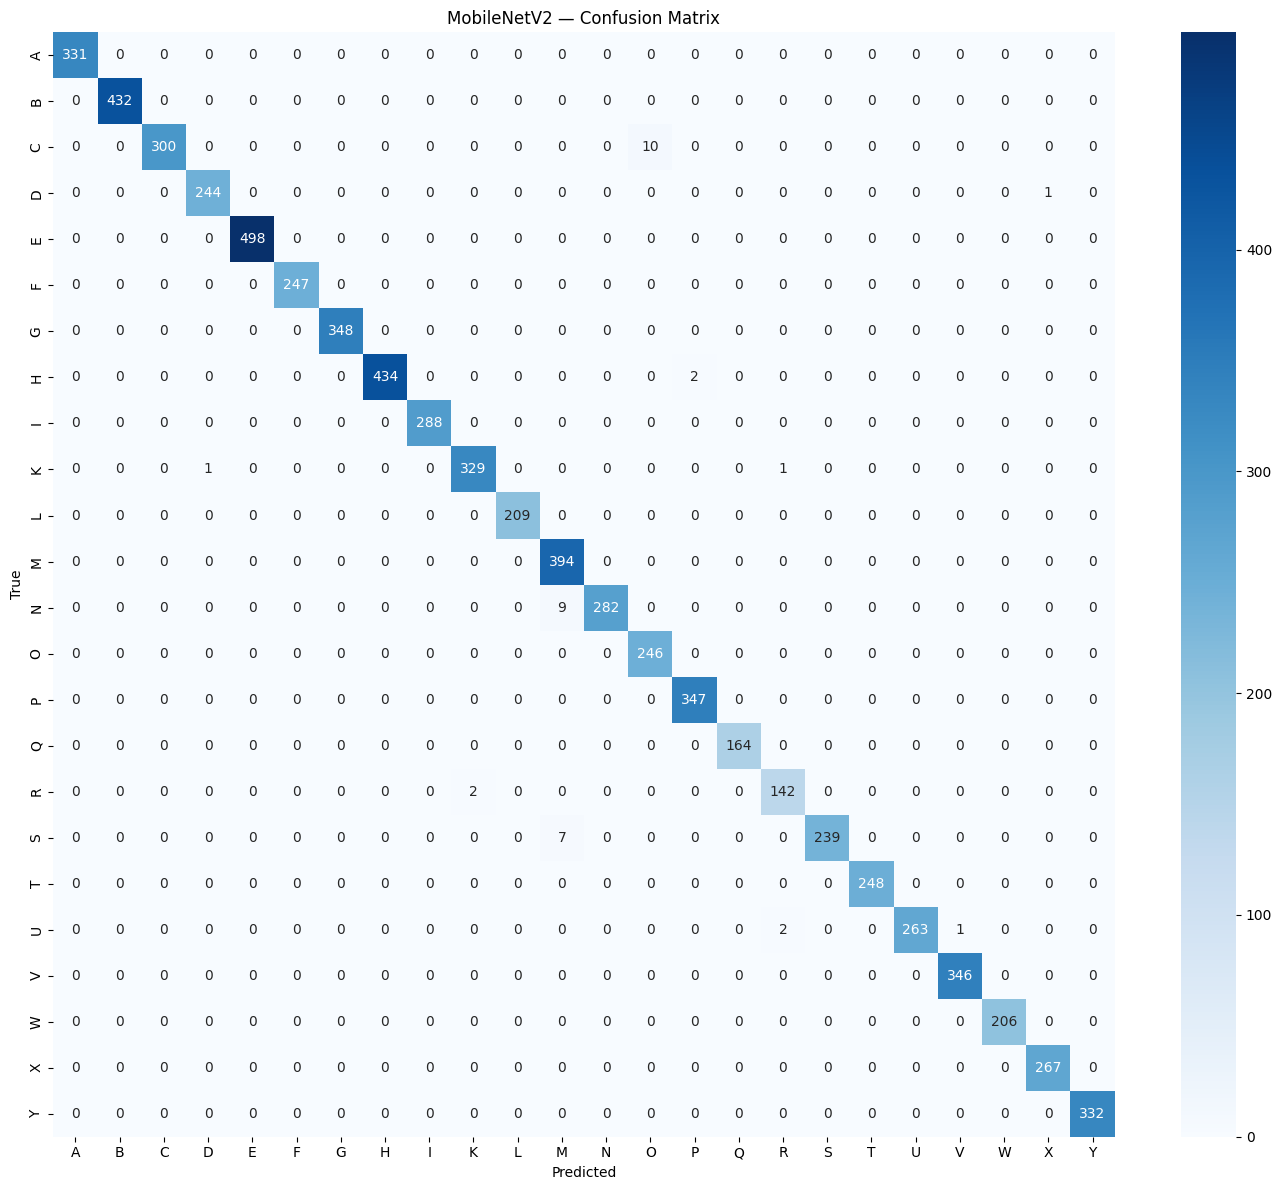

In [27]:
# ── Stage 2: Fine-tune last 30 layers ─────────────────────────────────────────
print("\n─── Stage 2: Fine-tuning ───")
mobilenet_base.trainable = True
for layer in mobilenet_base.layers[:-30]:
    layer.trainable = False

mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

mob_cb2 = [
    callbacks.EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    callbacks.ModelCheckpoint(f'{SAVE_DIR}/mobilenetv2_sign.h5', save_best_only=True, verbose=1)
]

history_mob2 = mobilenet_model.fit(
    train_ds_mob,
    epochs=15,
    validation_data=val_ds_mob,
    callbacks=mob_cb2
)
plot_history(history_mob2, 'MobileNetV2 — Stage 2 (Fine-tune)')
acc_mobile = evaluate_model(mobilenet_model, test_ds_mob, y_test, 'MobileNetV2', label_to_letter)


In [28]:
# ── Prepare EfficientNetB0 data as tf.data pipeline (avoids ~17 GB RAM spike) ──
_eff_SIZE  = 224
_eff_BATCH = 32

def make_eff_dataset(X, y, training=True, batch_size=_eff_BATCH):
    def preprocess(img, label):
        # EfficientNetB0 handles its own normalisation — pass [0, 255]
        img = tf.cast(img, tf.float32)                      # keep [0,255] range
        img = tf.expand_dims(img, axis=-1)                  # (28,28,1)
        img = tf.image.grayscale_to_rgb(img)                # (28,28,3)
        img = tf.image.resize(img, [_eff_SIZE, _eff_SIZE])
        return img, label

    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if training:
        ds = ds.shuffle(buffer_size=4096, seed=SEED)
    return (ds
            .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
            .batch(batch_size)
            .prefetch(tf.data.AUTOTUNE))

val_size_eff = int(0.1 * len(X_train_raw))
train_ds_eff = make_eff_dataset(X_train_raw[:-val_size_eff], y_train[:-val_size_eff], training=True)
val_ds_eff   = make_eff_dataset(X_train_raw[-val_size_eff:], y_train[-val_size_eff:], training=False)
test_ds_eff  = make_eff_dataset(X_test_raw, y_test, training=False)

print(f"EfficientNetB0 tf.data pipeline ready.")
print(f"  train batches: {len(train_ds_eff)}  val batches: {len(val_ds_eff)}  test batches: {len(test_ds_eff)}")


EfficientNetB0 tf.data pipeline ready.
  train batches: 773  val batches: 86  test batches: 225


In [29]:
# ── Build EfficientNetB0 ──────────────────────────────────────────────────────
def build_efficientnetb0(num_classes):
    base = applications.EfficientNetB0(weights='imagenet', include_top=False,
                                        input_shape=(224, 224, 3))
    base.trainable = False

    inputs = layers.Input(shape=(224, 224, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, outputs, name='EfficientNetB0_TL'), base

effnet_model, effnet_base = build_efficientnetb0(NUM_CLASSES)

effnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
effnet_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "EfficientNetB0_TL"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 24)             │         6,168 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,383,675 (16.72 MB)

 Trainable params: 334,104 (1.27 MB)

 Non-trainable params: 4,049,571 (15.45 MB)


─── Stage 1: Training classification head ───
Epoch 1/15
773/773 ━━━━━━━━━━━━━━━━━━━━ 92s 84ms/step - accuracy: 0.9169 - loss: 0.3086 - val_accuracy: 0.9996 - val_loss: 0.0107 - learning_rate: 0.0010
Epoch 2/15
773/773 ━━━━━━━━━━━━━━━━━━━━ 30s 39ms/step - accuracy: 0.9907 - loss: 0.0397 - val_accuracy: 0.9996 - val_loss: 0.0031 - learning_rate: 0.0010
Epoch 3/15
773/773 ━━━━━━━━━━━━━━━━━━━━ 30s 39ms/step - accuracy: 0.9930 - loss: 0.0280 - val_accuracy: 0.9989 - val_loss: 0.0031 - learning_rate: 0.0010
Epoch 4/15
773/773 ━━━━━━━━━━━━━━━━━━━━ 30s 38ms/step - accuracy: 0.9929 - loss: 0.0251 - val_accuracy: 1.0000 - val_loss: 9.8766e-04 - learning_rate: 0.0010
Epoch 5/15
773/773 ━━━━━━━━━━━━━━━━━━━━ 30s 39ms/step - accuracy: 0.9925 - loss: 0.0234 - val_accuracy: 1.0000 - val_loss: 4.3379e-04 - learning_rate: 0.0010
Epoch 6/15
773/773 ━━━━━━━━━━━━━━━━━━━━ 31s 39ms/step - accuracy: 0.9929 - loss: 0.0220 - val_accuracy: 0.9996 - val_loss: 0.0016 - learning_rate: 0.0010
Epoch 7/15
773/773 ━━

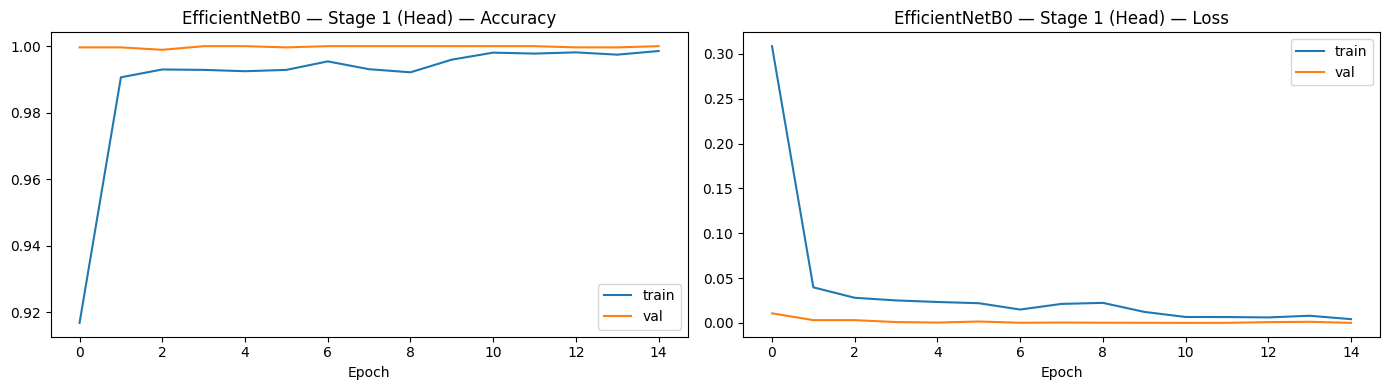

In [30]:
# ── Stage 1: Train head ───────────────────────────────────────────────────────
print("\n─── Stage 1: Training classification head ───")
eff_cb1 = [
    callbacks.EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(factor=0.5, patience=3, verbose=1),
]

history_eff1 = effnet_model.fit(
    train_ds_eff,
    epochs=15,
    validation_data=val_ds_eff,
    callbacks=eff_cb1
)
plot_history(history_eff1, 'EfficientNetB0 — Stage 1 (Head)')



─── Stage 2: Fine-tuning ───
Epoch 1/15
773/773 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.9694 - loss: 0.0987
Epoch 1: val_loss improved from None to 0.00053, saving model to /content/asl_models/efficientnetb0_sign.h5



Epoch 1: finished saving model to /content/asl_models/efficientnetb0_sign.h5
773/773 ━━━━━━━━━━━━━━━━━━━━ 87s 78ms/step - accuracy: 0.9790 - loss: 0.0666 - val_accuracy: 0.9996 - val_loss: 5.3352e-04
Epoch 2/15
772/773 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9903 - loss: 0.0304
Epoch 2: val_loss improved from 0.00053 to 0.00037, saving model to /content/asl_models/efficientnetb0_sign.h5



Epoch 2: finished saving model to /content/asl_models/efficientnetb0_sign.h5
773/773 ━━━━━━━━━━━━━━━━━━━━ 43s 45ms/step - accuracy: 0.9913 - loss: 0.0277 - val_accuracy: 0.9996 - val_loss: 3.7163e-04
Epoch 3/15
773/773 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9940 - loss: 0.0188
Epoch 3: val_loss improved from 0.00037 to 0.00018, saving model to /content/asl_models/efficientnetb0_sign.h5



Epoch 3: finished saving model to /content/asl_models/efficientnetb0_sign.h5
773/773 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.9937 - loss: 0.0192 - val_accuracy: 1.0000 - val_loss: 1.8012e-04
Epoch 4/15
771/773 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9961 - loss: 0.0146
Epoch 4: val_loss improved from 0.00018 to 0.00015, saving model to /content/asl_models/efficientnetb0_sign.h5



Epoch 4: finished saving model to /content/asl_models/efficientnetb0_sign.h5
773/773 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.9955 - loss: 0.0153 - val_accuracy: 1.0000 - val_loss: 1.5013e-04
Epoch 5/15
772/773 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9963 - loss: 0.0129
Epoch 5: val_loss improved from 0.00015 to 0.00008, saving model to /content/asl_models/efficientnetb0_sign.h5


...


Epoch 7: finished saving model to /content/asl_models/efficientnetb0_sign.h5
773/773 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.9972 - loss: 0.0093 - val_accuracy: 1.0000 - val_loss: 5.1119e-05
Epoch 8/15
771/773 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9975 - loss: 0.0072
Epoch 8: val_loss did not improve from 0.00005
773/773 ━━━━━━━━━━━━━━━━━━━━ 34s 44ms/step - accuracy: 0.9979 - loss: 0.0066 - val_accuracy: 1.0000 - val_loss: 5.1964e-05
Epoch 9/15
772/773 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9978 - loss: 0.0064
Epoch 9: val_loss improved from 0.00005 to 0.00003, saving model to /content/asl_models/efficientnetb0_sign.h5



Epoch 9: finished saving model to /content/asl_models/efficientnetb0_sign.h5
773/773 ━━━━━━━━━━━━━━━━━━━━ 34s 45ms/step - accuracy: 0.9979 - loss: 0.0068 - val_accuracy: 1.0000 - val_loss: 2.9319e-05
Epoch 10/15
773/773 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9979 - loss: 0.0058
Epoch 10: val_loss did not improve from 0.00003
773/773 ━━━━━━━━━━━━━━━━━━━━ 34s 44ms/step - accuracy: 0.9979 - loss: 0.0062 - val_accuracy: 1.0000 - val_loss: 3.9860e-05
Epoch 11/15
772/773 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9981 - loss: 0.0057
Epoch 11: val_loss did not improve from 0.00003
773/773 ━━━━━━━━━━━━━━━━━━━━ 34s 44ms/step - accuracy: 0.9981 - loss: 0.0053 - val_accuracy: 1.0000 - val_loss: 3.3751e-05
Epoch 12/15
772/773 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9978 - loss: 0.0075
Epoch 12: val_loss did not improve from 0.00003
773/773 ━━━━━━━━━━━━━━━━━━━━ 41s 45ms/step - accuracy: 0.9984 - loss: 0.0058 - val_accuracy: 1.0000 - val_loss: 2.9581e-05
Epoch 13/15
773/773 ━━


Epoch 13: finished saving model to /content/asl_models/efficientnetb0_sign.h5
773/773 ━━━━━━━━━━━━━━━━━━━━ 41s 45ms/step - accuracy: 0.9987 - loss: 0.0041 - val_accuracy: 1.0000 - val_loss: 2.6304e-05
Epoch 14/15
773/773 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9988 - loss: 0.0051
Epoch 14: val_loss improved from 0.00003 to 0.00002, saving model to /content/asl_models/efficientnetb0_sign.h5



Epoch 14: finished saving model to /content/asl_models/efficientnetb0_sign.h5
773/773 ━━━━━━━━━━━━━━━━━━━━ 41s 45ms/step - accuracy: 0.9987 - loss: 0.0044 - val_accuracy: 1.0000 - val_loss: 2.1385e-05
Epoch 15/15
772/773 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9987 - loss: 0.0034
Epoch 15: val_loss improved from 0.00002 to 0.00002, saving model to /content/asl_models/efficientnetb0_sign.h5



Epoch 15: finished saving model to /content/asl_models/efficientnetb0_sign.h5
773/773 ━━━━━━━━━━━━━━━━━━━━ 37s 48ms/step - accuracy: 0.9989 - loss: 0.0032 - val_accuracy: 1.0000 - val_loss: 2.0860e-05
Restoring model weights from the end of the best epoch: 15.


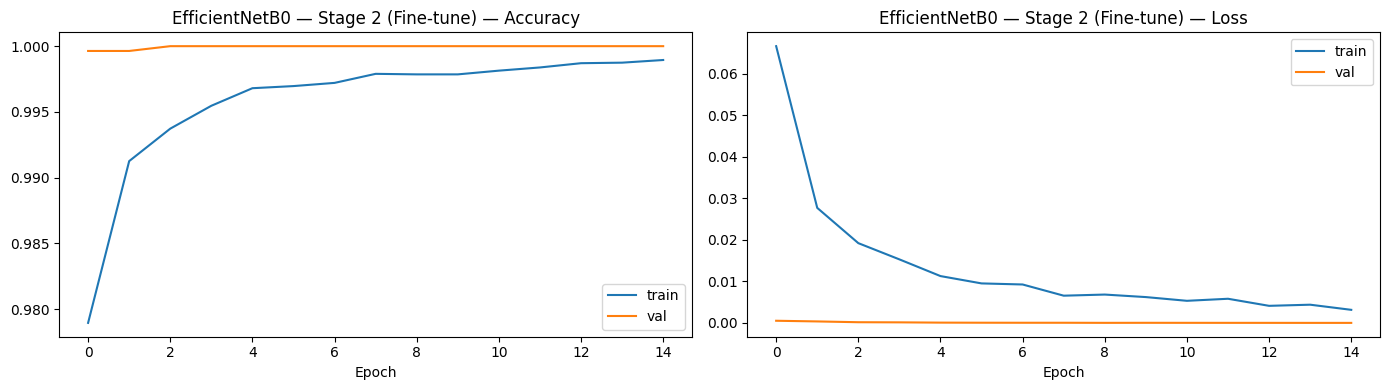


  EfficientNetB0
  Test Loss: 0.0003  |  Test Accuracy: 99.99%
              precision    recall  f1-score   support

           A       1.00      1.00      1.00       331
           B       1.00      1.00      1.00       432
           C       1.00      1.00      1.00       310
           D       1.00      1.00      1.00       245
           E       1.00      1.00      1.00       498
           F       1.00      1.00      1.00       247
           G       1.00      1.00      1.00       348
           H       1.00      1.00      1.00       436
           I       1.00      1.00      1.00       288
           K       1.00      1.00      1.00       331
           L       1.00      1.00      1.00       209
           M       1.00      1.00      1.00       394
           N       1.00      1.00      1.00       291
           O       1.00      1.00      1.00       246
           P       1.00      1.00      1.00       347
           Q       1.00      1.00      1.00       164
           R     

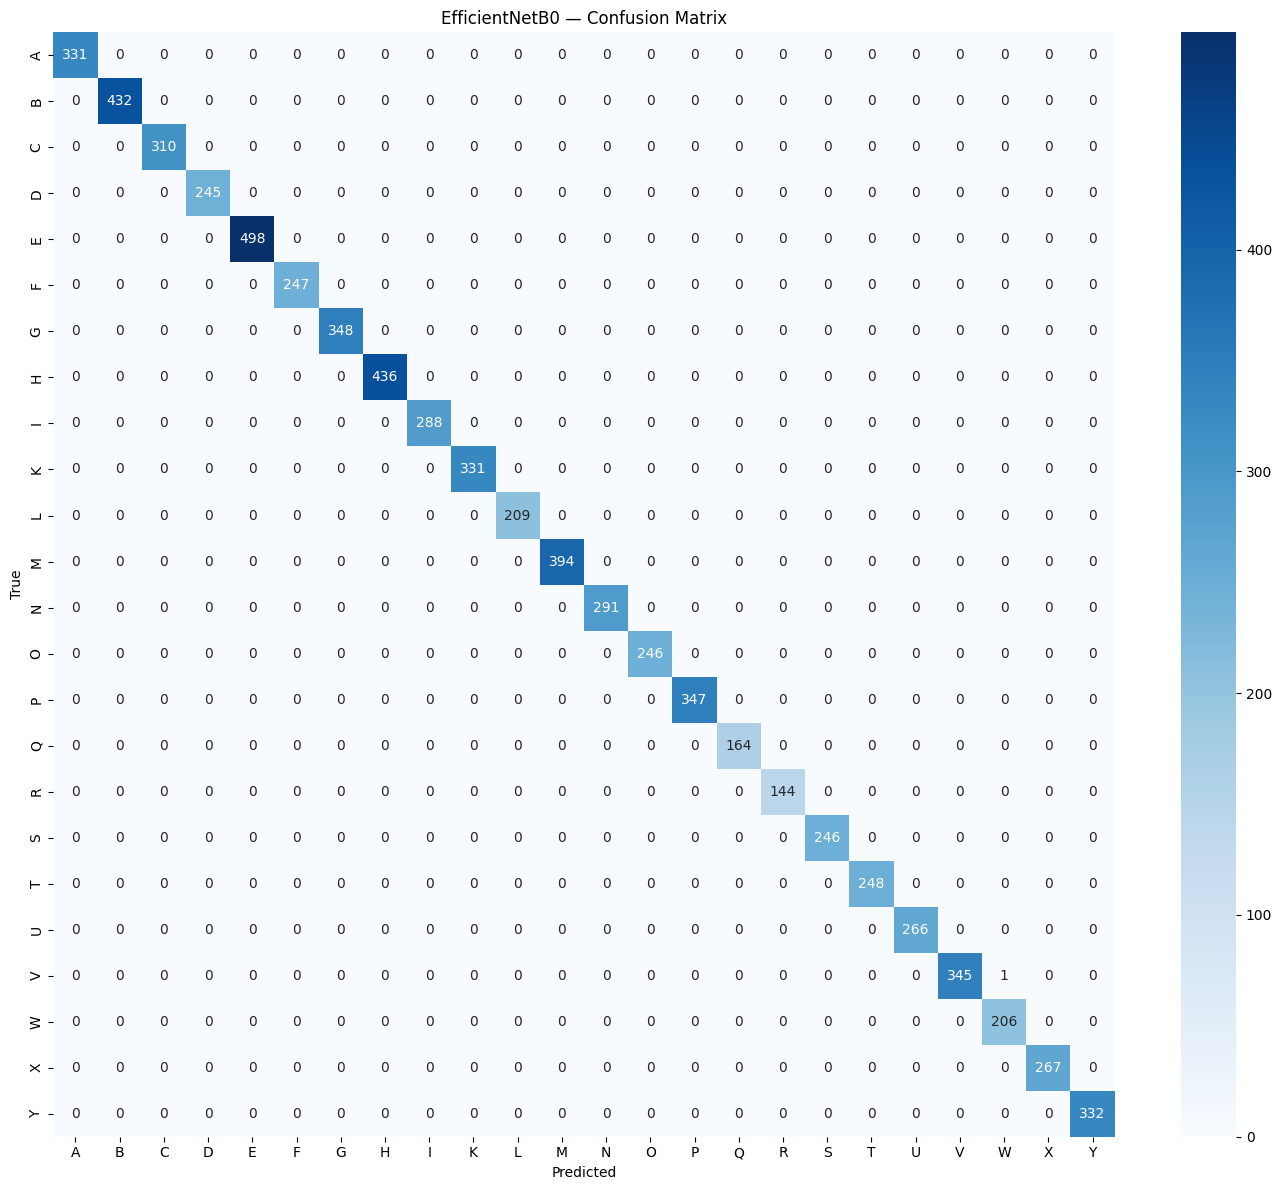

In [31]:
# ── Stage 2: Fine-tune ────────────────────────────────────────────────────────
print("\n─── Stage 2: Fine-tuning ───")
effnet_base.trainable = True
for layer in effnet_base.layers[:-20]:
    layer.trainable = False

effnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

eff_cb2 = [
    callbacks.EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    callbacks.ModelCheckpoint(f'{SAVE_DIR}/efficientnetb0_sign.h5', save_best_only=True, verbose=1)
]

history_eff2 = effnet_model.fit(
    train_ds_eff,
    epochs=15,
    validation_data=val_ds_eff,
    callbacks=eff_cb2
)
plot_history(history_eff2, 'EfficientNetB0 — Stage 2 (Fine-tune)')
acc_effnet = evaluate_model(effnet_model, test_ds_eff, y_test, 'EfficientNetB0', label_to_letter)


         Model Accuracy      Input Params(M)    Type               .h5 file
EfficientNetB0   99.99%    224×224      ~5.3    TL ✅ efficientnetb0_sign.h5
   MobileNetV2   99.50%      96×96      ~3.4    TL ✅    mobilenetv2_sign.h5
       AlexNet   98.69%    227×227       ~23 Scratch        alexnet_sign.h5
       LeNet-5   95.29% 28×28 Gray     ~0.06 Scratch          lenet_sign.h5
      ResNet50   88.59%    224×224       ~25      TL       resnet50_sign.h5
         VGG16    2.01%    224×224      ~138      TL          vgg16_sign.h5


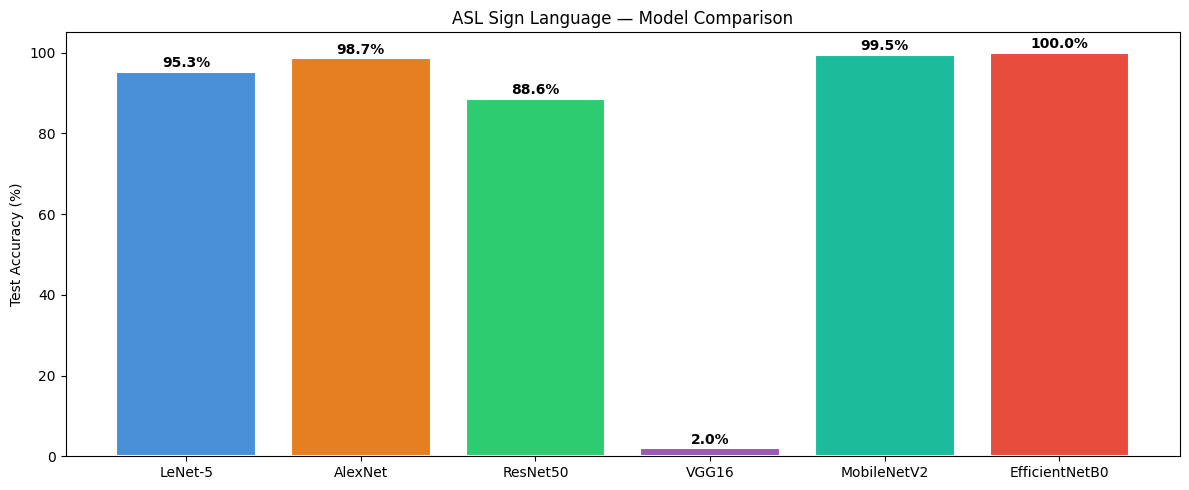


All .h5 files saved to: /content/asl_models


In [32]:
# ── Summary table ─────────────────────────────────────────────────────────────
results = {
    'Model':     ['LeNet-5',  'AlexNet',  'ResNet50', 'VGG16',   'MobileNetV2', 'EfficientNetB0'],
    'Accuracy':  [acc_lenet,  acc_alexnet, acc_resnet, acc_vgg,   acc_mobile,    acc_effnet],
    'Input':     ['28×28 Gray','227×227','224×224','224×224', '96×96',       '224×224'],
    'Params(M)': ['~0.06',    '~23',      '~25',      '~138',    '~3.4',        '~5.3'],
    'Type':      ['Scratch',  'Scratch',  'TL',       'TL',      'TL ✅',       'TL ✅'],
    '.h5 file':  ['lenet_sign.h5', 'alexnet_sign.h5', 'resnet50_sign.h5',
                  'vgg16_sign.h5', 'mobilenetv2_sign.h5', 'efficientnetb0_sign.h5']
}

df_results = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
df_results['Accuracy'] = df_results['Accuracy'].apply(lambda x: f"{x*100:.2f}%")
print(df_results.to_string(index=False))

# Bar chart
accs = [acc_lenet, acc_alexnet, acc_resnet, acc_vgg, acc_mobile, acc_effnet]
names = ['LeNet-5', 'AlexNet', 'ResNet50', 'VGG16', 'MobileNetV2', 'EfficientNetB0']
colors = ['#4A90D9','#E67E22','#2ECC71','#9B59B6','#1ABC9C','#E74C3C']

plt.figure(figsize=(12, 5))
bars = plt.bar(names, [a*100 for a in accs], color=colors, edgecolor='white', linewidth=1.5)
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{acc*100:.1f}%', ha='center', va='bottom', fontweight='bold')
plt.ylim(0, 105)
plt.ylabel('Test Accuracy (%)')
plt.title('ASL Sign Language — Model Comparison')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nAll .h5 files saved to:", SAVE_DIR)

In [33]:
import os

MODEL_FILES = [
    'lenet_sign.h5',
    'alexnet_sign.h5',
    'resnet50_sign.h5',
    'vgg16_sign.h5',
    'mobilenetv2_sign.h5',
    'efficientnetb0_sign.h5',
]

print(f"Models saved in: {SAVE_DIR}")
print("-" * 40)
for fname in MODEL_FILES:
    path = os.path.join(SAVE_DIR, fname)
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / 1e6
        print(f"  ✅  {fname}  ({size_mb:.1f} MB)")
    else:
        print(f"  ⚠️   {fname}  — not found (model may not have been trained yet)")

Models saved in: /content/asl_models
----------------------------------------
  ✅  lenet_sign.h5  (0.8 MB)
  ✅  alexnet_sign.h5  (700.7 MB)
  ✅  resnet50_sign.h5  (216.8 MB)
  ✅  vgg16_sign.h5  (120.4 MB)
  ✅  mobilenetv2_sign.h5  (25.7 MB)
  ✅  efficientnetb0_sign.h5  (31.5 MB)
